# **IMPORT LIBRARY**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anandaramg/global-superstore")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'global-superstore' dataset.
Path to dataset files: /kaggle/input/global-superstore


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mtick
import os

In [ ]:
filepath = os.path.join(path, 'Global Superstore.txt')
df = pd.read_csv(filepath, sep='\t')

In [ ]:
df.info()

# cek missing value
df.isnull().sum()

# cek duplikat
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer ID     51290 non-null  object 
 4   Customer Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order Date      51290 non-null  object 
 9   Order ID        51290 non-null  object 
 10  Order Priority  51290 non-null  object 
 11  Product ID      51290 non-null  object 
 12  Product Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row ID          51290 non-null  int64  
 17  Sales           51290 non-null 

np.int64(0)

In [ ]:
# Cek leading/trailing space
obj_cols = df.select_dtypes(include="object").columns
space_check = {}

for col in obj_cols:
    count = (df[col] != df[col].str.strip()).sum()
    if count > 0:
        space_check[col] = count

space_check

{}

# **DATA CLEANING**

In [ ]:
def clean_data(filepath):
    # tampilin data
    filepath = os.path.join(path, 'Global Superstore.txt')
    df = pd.read_csv(filepath, sep='\t')
    df

    # Convert tipe kolom date dr object jadi datetime
    df['Order Date'] = pd.to_datetime(df['Order Date'])
    df['Ship Date'] = pd.to_datetime(df['Ship Date'])

    # hapus kolom ga kepake
    cols_to_drop = ['记录数', 'Row ID']
    df = df.drop(columns=cols_to_drop, errors='ignore')

    # hapus spasi di tipe kolom object
    obj_cols = df.select_dtypes(include='object').columns
    df[obj_cols] = df[obj_cols].apply(lambda x: x.str.strip())

    # hapus baris yang duplikat
    df = df.drop_duplicates()

    return df

superstore = clean_data(filepath)

# cek ulang
display(superstore.head(5))
superstore.info()
superstore.isnull().sum()

categorical_cols = [
    "Category",
    "Sub-Category",
    "Segment",
    "Region",
    "Market",
    "Ship Mode",
    "Order Priority",
    "Country",
    "State",
    "City"
]

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(sorted(superstore[col].unique()))

,Category,City,Country,Customer ID,Customer Name,Discount,Market,Order Date,Order ID,Order Priority,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,2011-01-07,CA-2011-130813,High,...,19,Consumer,2011-01-09,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,2011-01-21,CA-2011-148614,Medium,...,19,Consumer,2011-01-26,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05,CA-2011-118962,Medium,...,21,Consumer,2011-08-09,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05,CA-2011-118962,Medium,...,111,Consumer,2011-08-09,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,2011-09-29,CA-2011-146969,High,...,6,Consumer,2011-10-03,Standard Class,1.32,California,Paper,2011,North America,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51290 non-null  object        
 1   City            51290 non-null  object        
 2   Country         51290 non-null  object        
 3   Customer ID     51290 non-null  object        
 4   Customer Name   51290 non-null  object        
 5   Discount        51290 non-null  float64       
 6   Market          51290 non-null  object        
 7   Order Date      51290 non-null  datetime64[ns]
 8   Order ID        51290 non-null  object        
 9   Order Priority  51290 non-null  object        
 10  Product ID      51290 non-null  object        
 11  Product Name    51290 non-null  object        
 12  Profit          51290 non-null  float64       
 13  Quantity        51290 non-null  int64         
 14  Region          51290 non-null  object        
 15  Sa

In [ ]:
#feature engineering

#1. nambahin shipping days
superstore["Shipping_Days"] = (
    superstore["Ship Date"] - superstore["Order Date"]
).dt.days

#2. nambahin profit margin
superstore["Profit_Margin"] = np.where(
    superstore["Sales"] != 0,
    superstore["Profit"] / superstore["Sales"],
    0
)

#3. nambahin lost_flag
superstore["Loss_Flag"] = np.where(
    superstore["Profit"] < 0,
    "Loss",
    "Profit"
)
#4. nambahin discount group
bins = [-0.01,0,0.1,0.2,0.3,0.4,1]

labels = [
    "0%",
    "0-10%",
    "10-20%",
    "20-30%",
    "30-40%",
    "40%+"
]

superstore["Discount_Group"] = pd.cut(
    superstore["Discount"],
    bins=bins,
    labels=labels
)
#5. nambahin sales category
superstore["Sales_Category"] = pd.qcut(
    superstore["Sales"],
    q=3,
    labels=["Low","Medium","High"]
)
#6. nambahin Order month
superstore["Order_Month"] = superstore["Order Date"].dt.month_name()

#7. nambahin Order quater
superstore["Order_Quarter"] = (
    "Q" +
    superstore["Order Date"].dt.quarter.astype(str)
)
#7. nambahin Order year
superstore["Order_Year"] = superstore["Order Date"].dt.year

#7. nambahin Order Weekday
superstore["Order_Weekday"] = (
    superstore["Order Date"]
    .dt.day_name()
)

In [ ]:
display(superstore.head(5))

,Category,City,Country,Customer ID,Customer Name,Discount,Market,Order Date,Order ID,Order Priority,...,weeknum,Shipping_Days,Profit_Margin,Loss_Flag,Discount_Group,Sales_Category,Order_Month,Order_Quarter,Order_Year,Order_Weekday
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,2011-01-07,CA-2011-130813,High,...,2,2,0.491116,Profit,0%,Low,January,Q1,2011,Friday
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,2011-01-21,CA-2011-148614,Medium,...,4,5,0.489095,Profit,0%,Low,January,Q1,2011,Friday
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05,CA-2011-118962,Medium,...,32,4,0.468657,Profit,0%,Low,August,Q3,2011,Friday
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05,CA-2011-118962,Medium,...,32,4,0.479827,Profit,0%,Medium,August,Q3,2011,Friday
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,2011-09-29,CA-2011-146969,High,...,40,4,0.518400,Profit,0%,Low,September,Q3,2011,Thursday


# **Analisis 1- Profit**

Tren Sales dan Profit Tahunan:


,Order_Year,Sales,Profit
0,2011,2259511,248940.81154
1,2012,2677493,307415.27910
2,2013,3405860,406935.23018
3,2014,4300041,504165.97046


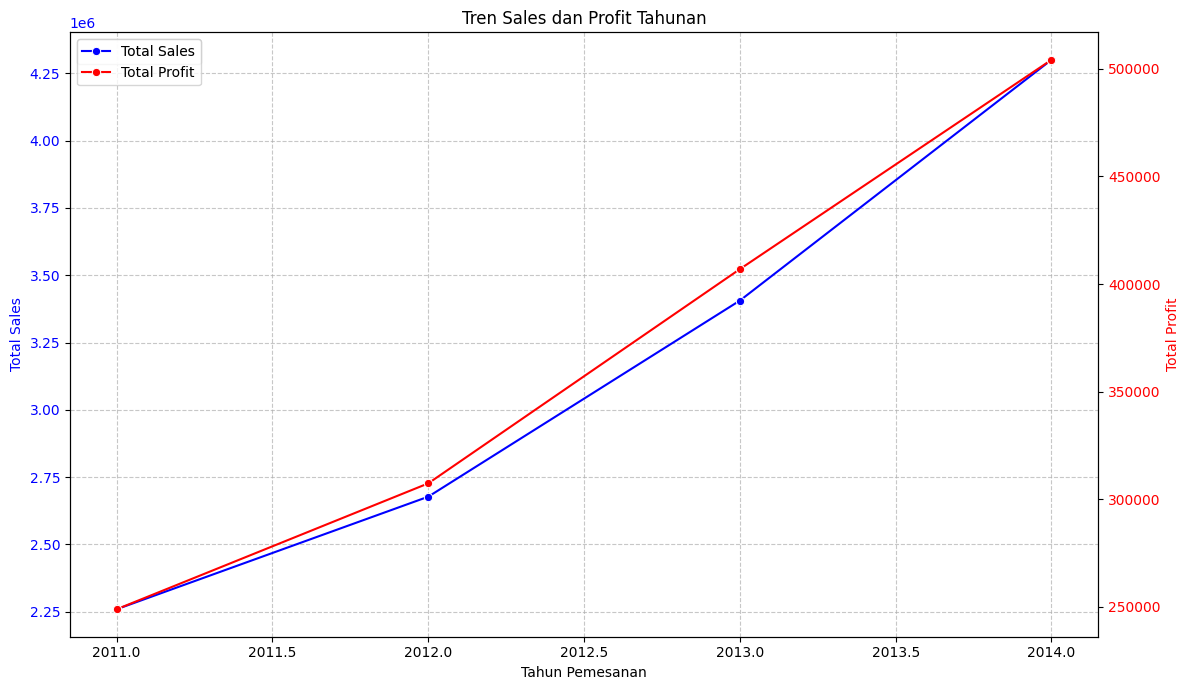

In [ ]:
yearly_performance = superstore.groupby('Order_Year')[['Sales', 'Profit']].sum().reset_index()

print('Tren Sales dan Profit Tahunan:')
display(yearly_performance)

# Create a line chart for Sales and Profit
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot Sales
sns.lineplot(x='Order_Year', y='Sales', data=yearly_performance, marker='o', color='blue', ax=ax1, label='Total Sales')
ax1.set_xlabel('Tahun Pemesanan')
ax1.set_ylabel('Total Sales', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Tren Sales dan Profit Tahunan')
ax1.grid(True, linestyle='--', alpha=0.7)

# Create a second y-axis for Profit
ax2 = ax1.twinx()
sns.lineplot(x='Order_Year', y='Profit', data=yearly_performance, marker='o', color='red', ax=ax2, label='Total Profit')
ax2.set_ylabel('Total Profit', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

**Insight :** Total sales menunjukkan tren pertumbuhan yang konsisten dari tahun 2011 hingga 2014. Sejalan dengan itu, total profit juga terus meningkat. Hal ini menunjukkan bahwa peningkatan omzet masih diikuti oleh peningkatan laba perusahaan.

Tren Profit Tahunan per Region:


,Order_Year,Region,Profit
0,2011,Africa,"$10,944.11"
1,2011,Canada,"$1,807.08"
2,2011,Caribbean,"$4,358.91"
3,2011,Central,"$52,678.47"
4,2011,Central Asia,"$22,846.45"
5,2011,EMEA,"$5,280.03"
6,2011,East,"$17,059.61"
7,2011,North,"$35,866.23"
8,2011,North Asia,"$35,513.37"
9,2011,Oceania,"$21,428.76"


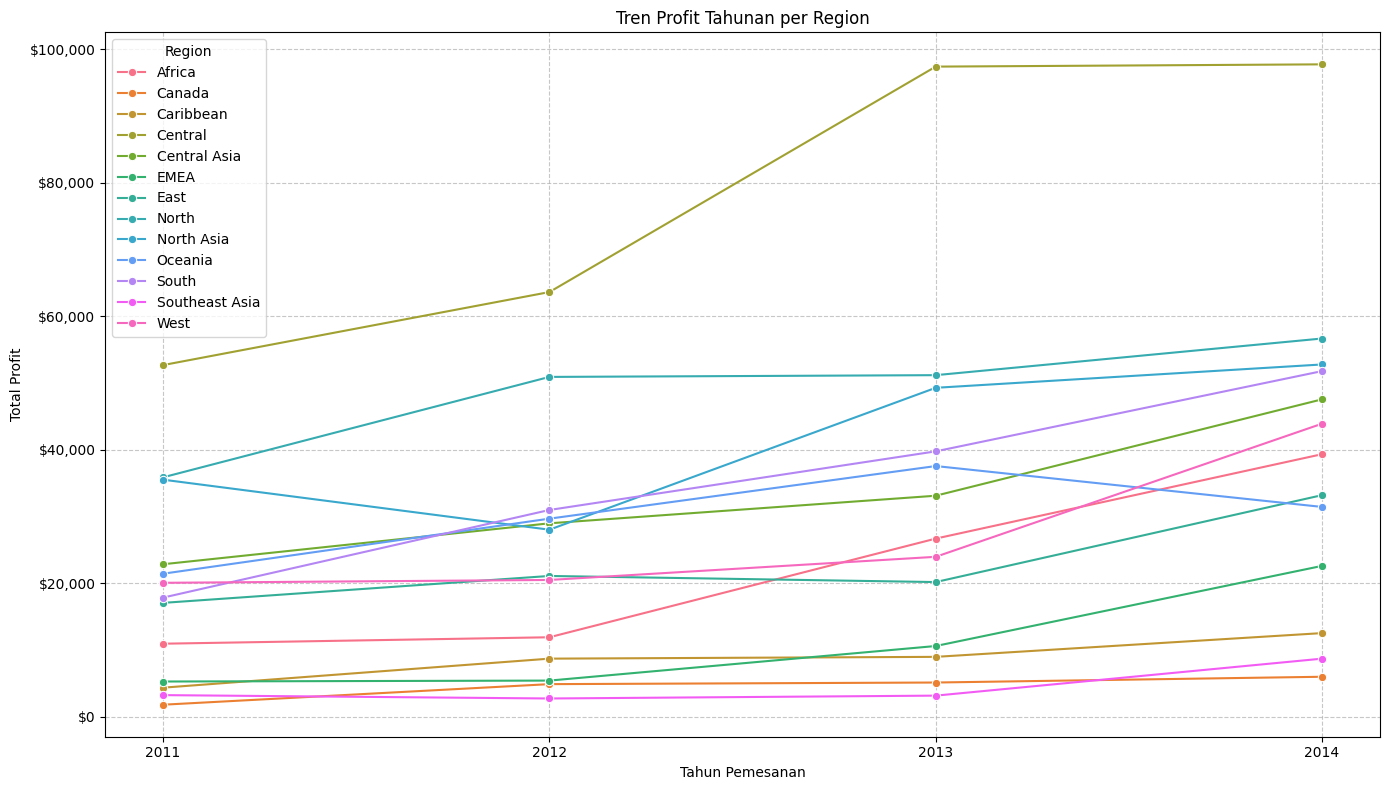

In [ ]:
regional_yearly_profit = superstore.groupby(['Order_Year', 'Region'])['Profit'].sum().reset_index()

print('Tren Profit Tahunan per Region:')
display(regional_yearly_profit.style.format({'Profit': '${:,.2f}'}))

plt.figure(figsize=(14, 8))
sns.lineplot(x='Order_Year', y='Profit', hue='Region', data=regional_yearly_profit, marker='o')
plt.title('Tren Profit Tahunan per Region')
plt.xlabel('Tahun Pemesanan')
plt.ylabel('Total Profit')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(regional_yearly_profit['Order_Year'].unique())
plt.legend(title='Region')

# Format y-axis as currency
def currency_formatter(x, pos):
    return '${:,.0f}'.format(x)

formatter = FuncFormatter(currency_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

#**Analisis** **2**-**Profit** **Leakage** **Analysis**

In [ ]:
#Untuk mengetahui skala atau seberapa besar masalah kerugian yang sedang dihadapi perusahaan secara keseluruhan.
loss_df = df[df["Profit"] < 0]

print("Jumlah transaksi rugi :", len(loss_df))
print("Total kerugian :", loss_df["Profit"].sum())

Jumlah transaksi rugi : 12544
Total kerugian : -920646.1557200002


Total Kerugian Tahunan:


,Order_Year,Profit
0,2011,"$-169,308.16"
1,2012,"$-195,342.34"
2,2013,"$-245,907.19"
3,2014,"$-310,088.47"


/tmp/ipykernel_68392/1644735464.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Order_Year', y='Profit', data=yearly_loss, palette='Reds')


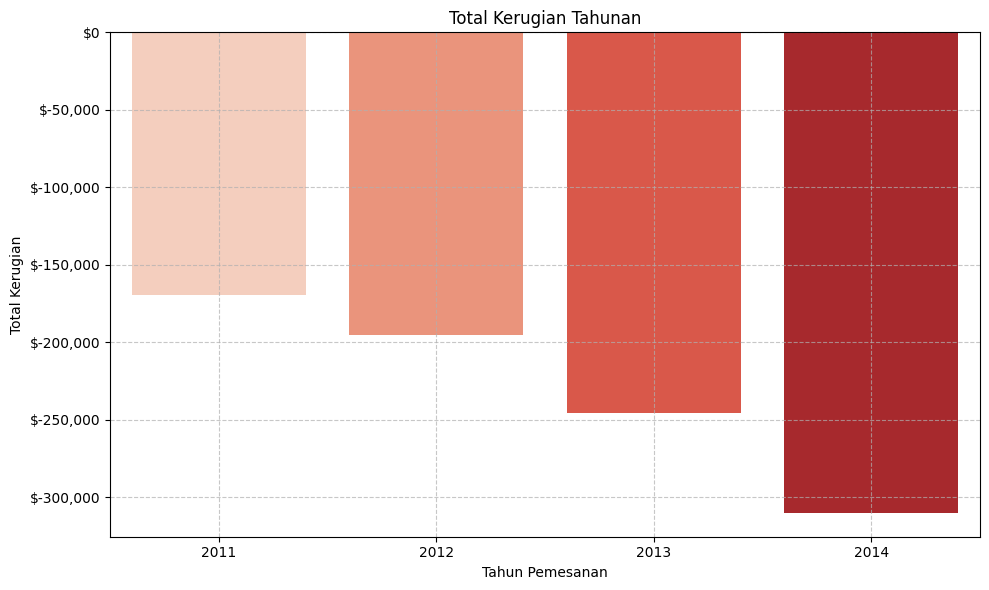

In [ ]:
#Melihat total Kerugian tiap tahun nya
yearly_loss = superstore[superstore['Profit'] < 0].groupby('Order_Year')['Profit'].sum().reset_index()

print('Total Kerugian Tahunan:')
display(yearly_loss.style.format({'Profit': '${:,.2f}'}))

plt.figure(figsize=(10, 6))
sns.barplot(x='Order_Year', y='Profit', data=yearly_loss, palette='Reds')
plt.title('Total Kerugian Tahunan')
plt.xlabel('Tahun Pemesanan')
plt.ylabel('Total Kerugian')

def currency_formatter(x, pos):
    return '${:,.0f}'.format(x)

formatter = FuncFormatter(currency_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Total Kerugian Tahunan per Region:


,Order_Year,Region,Profit
0,2011,Africa,"$-16,812.78"
1,2011,Caribbean,"$-5,116.90"
2,2011,Central,"$-39,062.46"
3,2011,Central Asia,"$-3,940.79"
4,2011,EMEA,"$-23,169.52"
5,2011,East,"$-8,397.98"
6,2011,North,"$-6,345.48"
7,2011,North Asia,"$-9,272.08"
8,2011,Oceania,"$-8,061.39"
9,2011,South,"$-30,527.87"


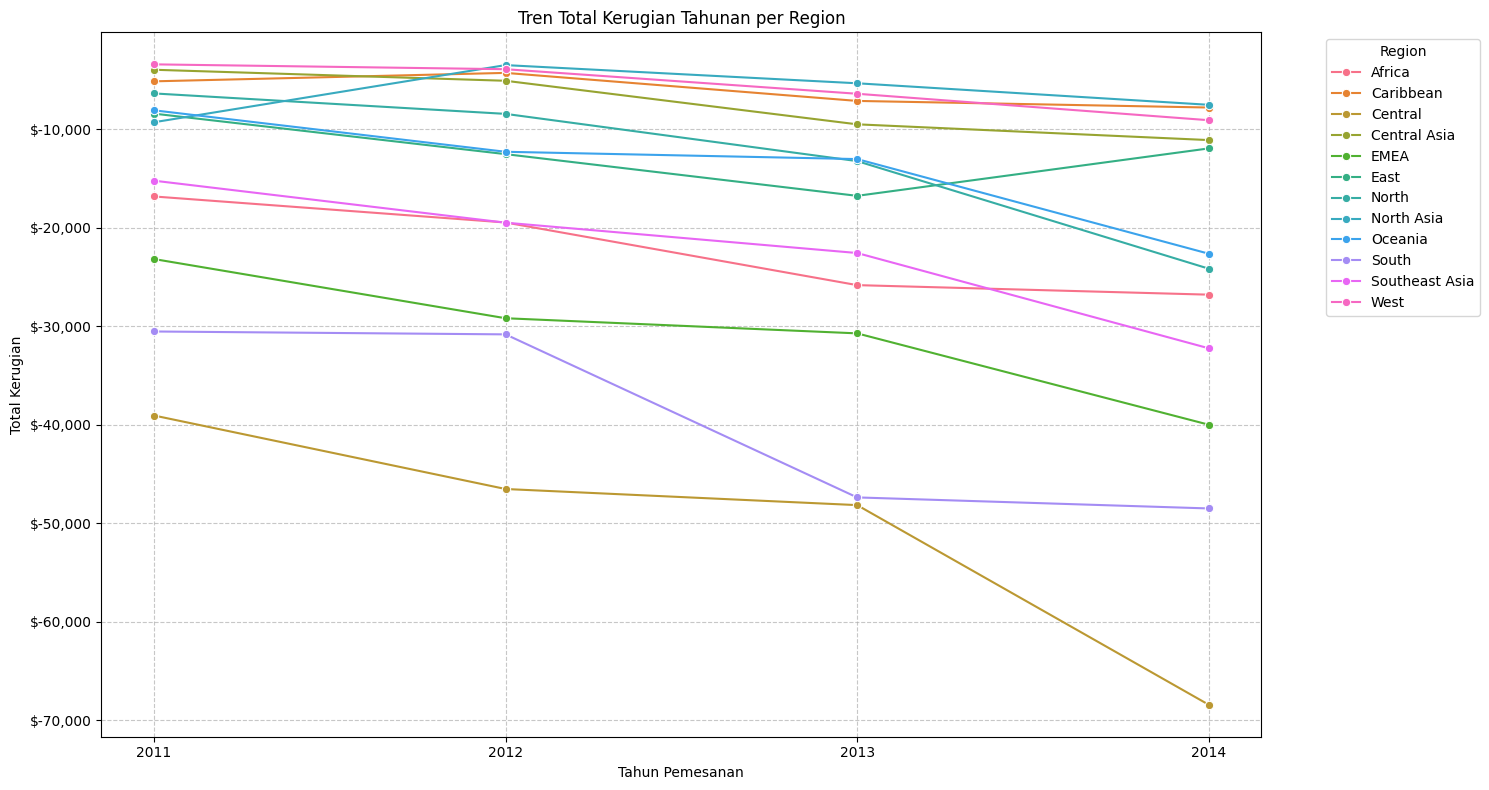

In [ ]:
regional_yearly_loss = superstore[superstore['Profit'] < 0].groupby(['Order_Year', 'Region'])['Profit'].sum().reset_index()

print('Total Kerugian Tahunan per Region:')
display(regional_yearly_loss.style.format({'Profit': '${:,.2f}'}))

plt.figure(figsize=(15, 8))
sns.lineplot(x='Order_Year', y='Profit', hue='Region', data=regional_yearly_loss, marker='o')
plt.title('Tren Total Kerugian Tahunan per Region')
plt.xlabel('Tahun Pemesanan')
plt.ylabel('Total Kerugian')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(regional_yearly_loss['Order_Year'].unique())
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

def currency_formatter(x, pos):
    return '${:,.0f}'.format(x)

formatter = FuncFormatter(currency_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

Disini terlihat kalo region central menjadi penyumbang profit tertinggi dan kerugian terbesar

### Analisis Profit dan Kerugian di Regional 'Central'


Profit Tahunan Regional 'Central':


,Order_Year,Region,Profit
3,2011,Central,"$52,678.47"
16,2012,Central,"$63,617.31"
29,2013,Central,"$97,384.63"
42,2014,Central,"$97,723.57"


Kerugian Tahunan Regional 'Central':


,Order_Year,Region,Profit
2,2011,Central,"$-39,062.46"
14,2012,Central,"$-46,528.93"
26,2013,Central,"$-48,165.09"
38,2014,Central,"$-68,439.88"


Ringkasan Profit dan Kerugian Tahunan Regional 'Central':


,Order_Year,Region,Profit_Profit,Profit_Loss,Total Net Profit
0,2011,Central,"$52,678.47","$-39,062.46","$13,616.01"
1,2012,Central,"$63,617.31","$-46,528.93","$17,088.37"
2,2013,Central,"$97,384.63","$-48,165.09","$49,219.54"
3,2014,Central,"$97,723.57","$-68,439.88","$29,283.69"


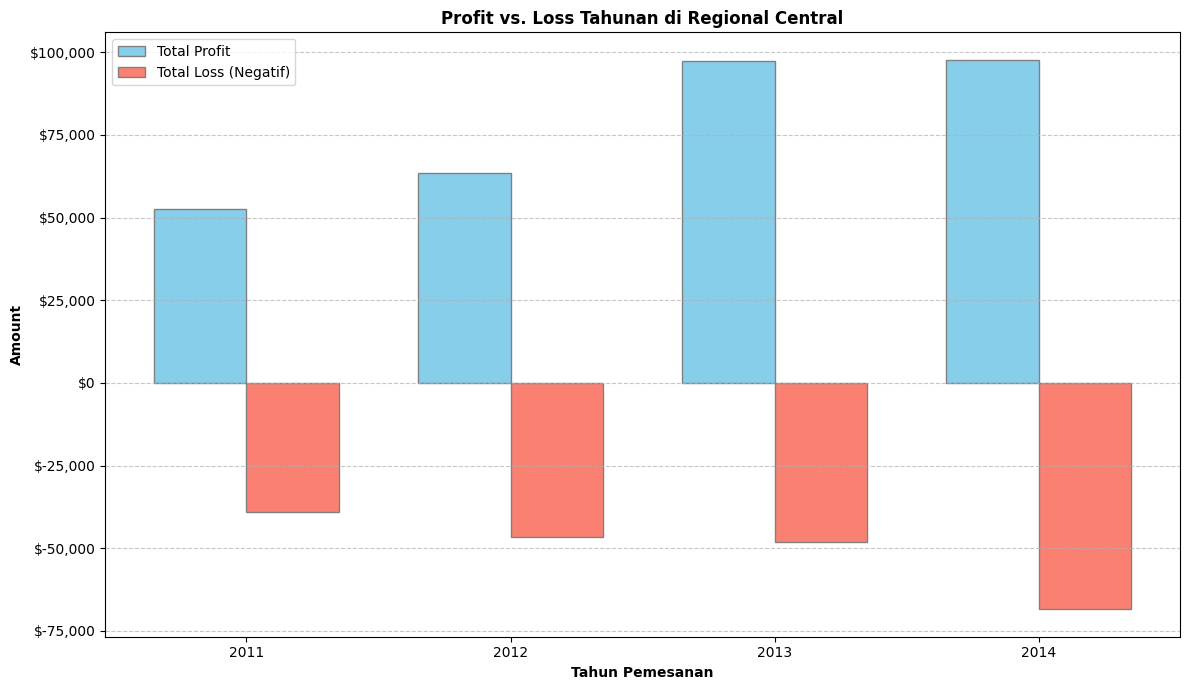

In [ ]:
# Filter profit dan loss untuk regional 'Central'
central_profit = regional_yearly_profit[regional_yearly_profit['Region'] == 'Central']
central_loss = regional_yearly_loss[regional_yearly_loss['Region'] == 'Central']

print("Profit Tahunan Regional 'Central':")
display(central_profit.style.format({'Profit': '${:,.2f}'}))

print("Kerugian Tahunan Regional 'Central':")
display(central_loss.style.format({'Profit': '${:,.2f}'}))

# Gabungkan profit dan loss untuk visualisasi yang lebih baik
central_summary = pd.merge(central_profit, central_loss, on=['Order_Year', 'Region'], suffixes=('_Profit', '_Loss'))
central_summary['Total Net Profit'] = central_summary['Profit_Profit'] + central_summary['Profit_Loss']

print("Ringkasan Profit dan Kerugian Tahunan Regional 'Central':")
display(central_summary.style.format({
    'Profit_Profit': '${:,.2f}',
    'Profit_Loss': '${:,.2f}',
    'Total Net Profit': '${:,.2f}'
}))

fig, ax = plt.subplots(figsize=(12, 7))

bar_width = 0.35
r1 = np.arange(len(central_summary['Order_Year']))
r2 = [x + bar_width for x in r1]

# Plot Profit dan Loss
plt.bar(r1, central_summary['Profit_Profit'], color='skyblue', width=bar_width, edgecolor='grey', label='Total Profit')
plt.bar(r2, central_summary['Profit_Loss'], color='salmon', width=bar_width, edgecolor='grey', label='Total Loss (Negatif)')

plt.xlabel('Tahun Pemesanan', fontweight='bold')
plt.ylabel('Amount', fontweight='bold')
plt.title('Profit vs. Loss Tahunan di Regional Central', fontweight='bold')
plt.xticks([r + bar_width / 2 for r in range(len(central_summary['Order_Year']))], central_summary['Order_Year'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

formatter = FuncFormatter(currency_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

Dari ringkasan di atas, terlihat bahwa **Regional Central** secara konsisten menghasilkan profit yang tinggi, namun juga menanggung kerugian yang signifikan setiap tahunnya. Hal ini menunjukkan bahwa ada transaksi-transaksi yang sangat menguntungkan di wilayah ini, tetapi juga ada sejumlah besar transaksi yang merugikan.  Fenomena ini sering terjadi pada wilayah dengan volume penjualan dan aktivitas bisnis yang tinggi.

Untuk memahami lebih lanjut, mari kita selidiki lebih dalam penyebab kerugian di Regional Central. Kita akan melihat kategori produk dan grup diskon yang paling banyak menyumbang kerugian.

In [ ]:
central_region_data = superstore[superstore['Region'] == 'Central']

country_profit_central = central_region_data.groupby('Country')['Profit'].sum().reset_index()

print("Negara dengan Profit Tertinggi di Regional Central:")
display(country_profit_central.sort_values(by='Profit', ascending=False).head(10).style.format({'Profit': '${:,.2f}'}))

print("\nNegara dengan Kerugian Terbanyak di Regional Central:")
display(country_profit_central.sort_values(by='Profit', ascending=True).head(10).style.format({'Profit': '${:,.2f}'}))

Negara dengan Profit Tertinggi di Regional Central:


,Country,Profit
3,France,"$109,029.00"
4,Germany,"$107,322.82"
2,El Salvador,"$42,023.24"
11,United States,"$39,706.36"
8,Nicaragua,"$33,401.44"
5,Guatemala,"$27,944.69"
0,Austria,"$21,442.26"
1,Belgium,"$11,572.59"
10,Switzerland,"$7,237.47"
9,Panama,"$-17,723.45"



Negara dengan Kerugian Terbanyak di Regional Central:


,Country,Profit
7,Netherlands,"$-41,070.07"
6,Honduras,"$-29,482.37"
9,Panama,"$-17,723.45"
10,Switzerland,"$7,237.47"
1,Belgium,"$11,572.59"
0,Austria,"$21,442.26"
5,Guatemala,"$27,944.69"
8,Nicaragua,"$33,401.44"
11,United States,"$39,706.36"
2,El Salvador,"$42,023.24"


Kerugian Berdasarkan Kategori Produk di Regional Central:


,Profit
Category,
Furniture,"$-81,991.80"
Office Supplies,"$-63,748.31"
Technology,"$-56,456.25"


/tmp/ipykernel_68392/1232160791.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loss_by_category_central.index, y=loss_by_category_central.values, palette='viridis')


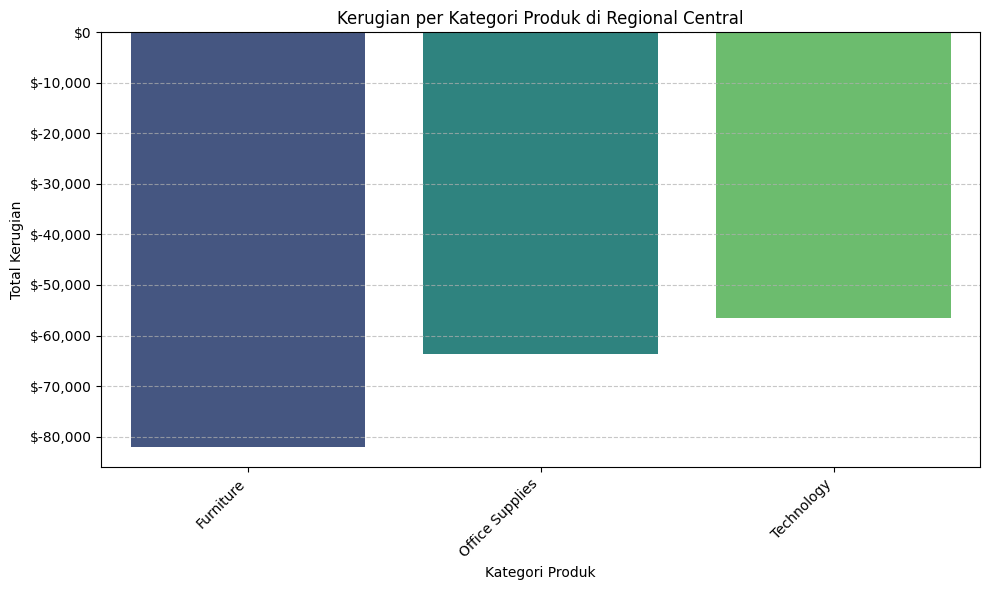

In [ ]:
# Filter transaksi merugi di Regional Central
central_loss_transactions = superstore[(superstore['Region'] == 'Central') & (superstore['Profit'] < 0)]

# Analisis kerugian berdasarkan Kategori Produk
loss_by_category_central = central_loss_transactions.groupby('Category')['Profit'].sum().sort_values()

print("Kerugian Berdasarkan Kategori Produk di Regional Central:")
display(loss_by_category_central.to_frame().style.format({'Profit': '${:,.2f}'}))

# Visualisasi kerugian berdasarkan Kategori Produk
fig = plt.figure(figsize=(10, 6))
sns.barplot(x=loss_by_category_central.index, y=loss_by_category_central.values, palette='viridis')
plt.title('Kerugian per Kategori Produk di Regional Central')
plt.xlabel('Kategori Produk')
plt.ylabel('Total Kerugian')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
formatter = FuncFormatter(currency_formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.show()


Kerugian Berdasarkan Grup Diskon di Regional Central:


/tmp/ipykernel_68392/3248295778.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loss_by_discount_central = central_loss_transactions.groupby('Discount_Group')['Profit'].sum().sort_values()


,Profit
Discount_Group,
40%+,"$-125,916.72"
30-40%,"$-51,163.50"
10-20%,"$-12,064.56"
20-30%,"$-6,928.30"
0-10%,"$-6,123.29"
0%,$0.00


/tmp/ipykernel_68392/3248295778.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loss_by_discount_central.index, y=loss_by_discount_central.values, palette='magma')


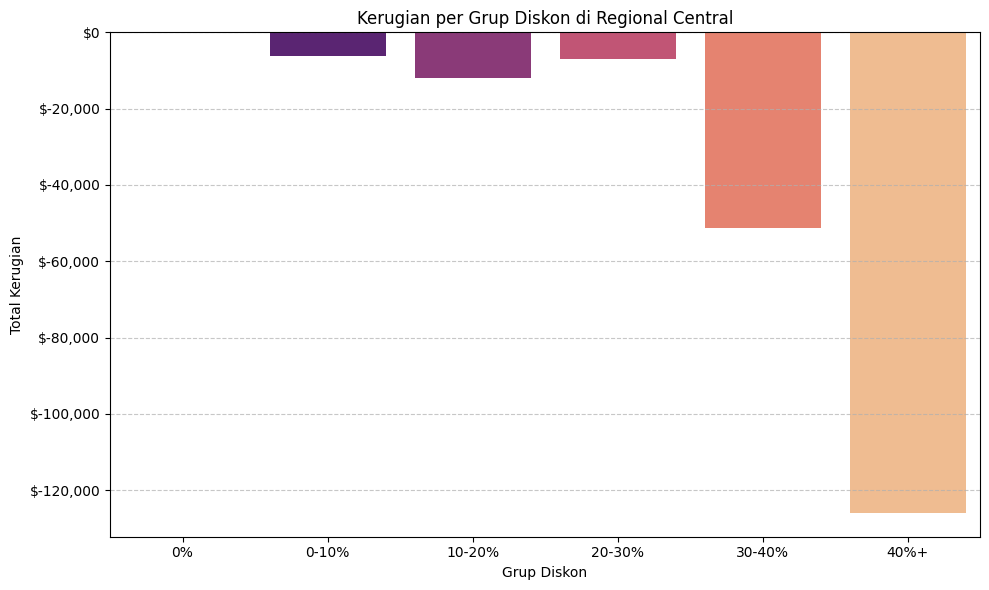

In [ ]:
# Analisis kerugian berdasarkan Grup Diskon di Regional Central
loss_by_discount_central = central_loss_transactions.groupby('Discount_Group')['Profit'].sum().sort_values()

print("Kerugian Berdasarkan Grup Diskon di Regional Central:")
display(loss_by_discount_central.to_frame().style.format({'Profit': '${:,.2f}'}))

# Visualisasi kerugian berdasarkan Grup Diskon
fig = plt.figure(figsize=(10, 6))
sns.barplot(x=loss_by_discount_central.index, y=loss_by_discount_central.values, palette='magma')
plt.title('Kerugian per Grup Diskon di Regional Central')
plt.xlabel('Grup Diskon')
plt.ylabel('Total Kerugian')
plt.grid(axis='y', linestyle='--', alpha=0.7)
formatter = FuncFormatter(currency_formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.show()

10 Negara dengan Kerugian Terbanyak:


,Country,Profit
0,United States,"$-156,131.29"
1,Turkey,"$-98,447.23"
2,Nigeria,"$-80,750.72"
3,Brazil,"$-42,073.08"
4,Netherlands,"$-41,470.41"
5,Australia,"$-40,907.75"
6,Indonesia,"$-34,510.12"
7,Italy,"$-34,349.24"
8,France,"$-33,875.89"
9,Honduras,"$-30,538.18"


/tmp/ipykernel_68392/2657596723.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Country', y='Profit', data=country_loss, palette='rocket')


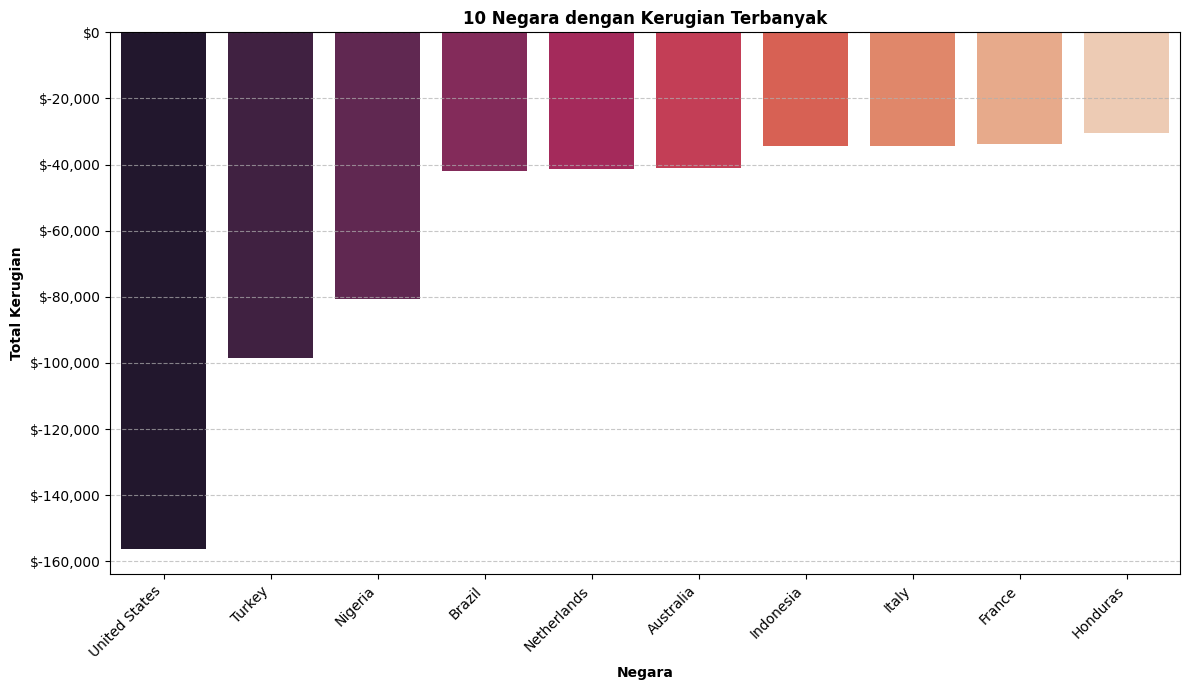

In [ ]:
# Identifikasi 10 negara dengan kerugian terbanyak
country_loss = superstore[superstore['Profit'] < 0].groupby('Country')['Profit'].sum().nsmallest(10).reset_index()

print("10 Negara dengan Kerugian Terbanyak:")
display(country_loss.style.format({'Profit': '${:,.2f}'}))

# Visualisasi 10 negara dengan kerugian terbanyak
fig = plt.figure(figsize=(12, 7))
sns.barplot(x='Country', y='Profit', data=country_loss, palette='rocket')
plt.title('10 Negara dengan Kerugian Terbanyak', fontweight='bold')
plt.xlabel('Negara', fontweight='bold')
plt.ylabel('Total Kerugian', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

formatter = FuncFormatter(currency_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

In [ ]:
#Definisikan "Loss Transaction"
loss_df = df[df["Profit"] < 0]

print(f"Jumlah transaksi rugi : {len(loss_df)}")
print(f"Total transaksi       : {len(df)}")

print(
    f"Persentase rugi : {(len(loss_df)/len(df))*100:.2f}%"
)

print(
    f"Total kerugian : {loss_df['Profit'].sum():,.2f}"
)

Jumlah transaksi rugi : 12544
Total transaksi       : 51290
Persentase rugi : 24.46%
Total kerugian : -920,646.16


,Total_Loss,Transactions,Avg_Loss
Category,,,
Furniture,"$-370,168.84",3117,$-118.76
Technology,"$-286,495.40",2424,$-118.19
Office Supplies,"$-263,981.92",7003,$-37.70


/tmp/ipykernel_68392/2046695636.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loss_category.index, y='Total_Loss', data=loss_category, palette='viridis')


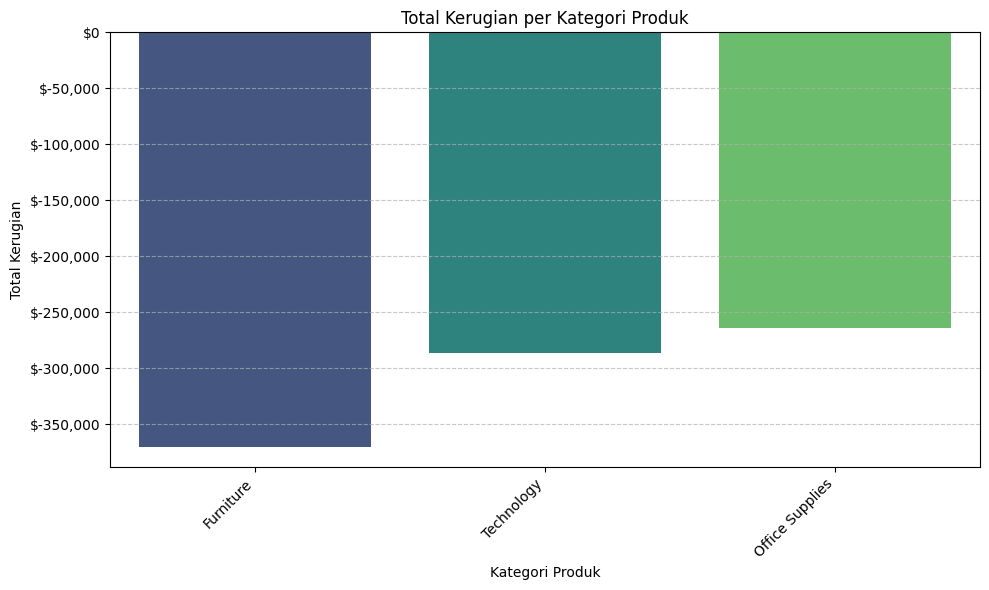

In [ ]:
#Kategori mana yang menyumbang kerugian terbesar?
loss_category = (
    loss_df
    .groupby("Category")
    .agg(
        Total_Loss=("Profit", "sum"),
        Transactions=("Order ID", "count"),
        Avg_Loss=("Profit", "mean")
    )
    .sort_values("Total_Loss")
)

display(loss_category.style.format({'Total_Loss': '${:,.2f}', 'Avg_Loss': '${:,.2f}'}))

# Visualisasi kerugian berdasarkan Kategori Produk
fig = plt.figure(figsize=(10, 6))
sns.barplot(x=loss_category.index, y='Total_Loss', data=loss_category, palette='viridis')
plt.title('Total Kerugian per Kategori Produk')
plt.xlabel('Kategori Produk')
plt.ylabel('Total Kerugian')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
formatter = FuncFormatter(currency_formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.show()

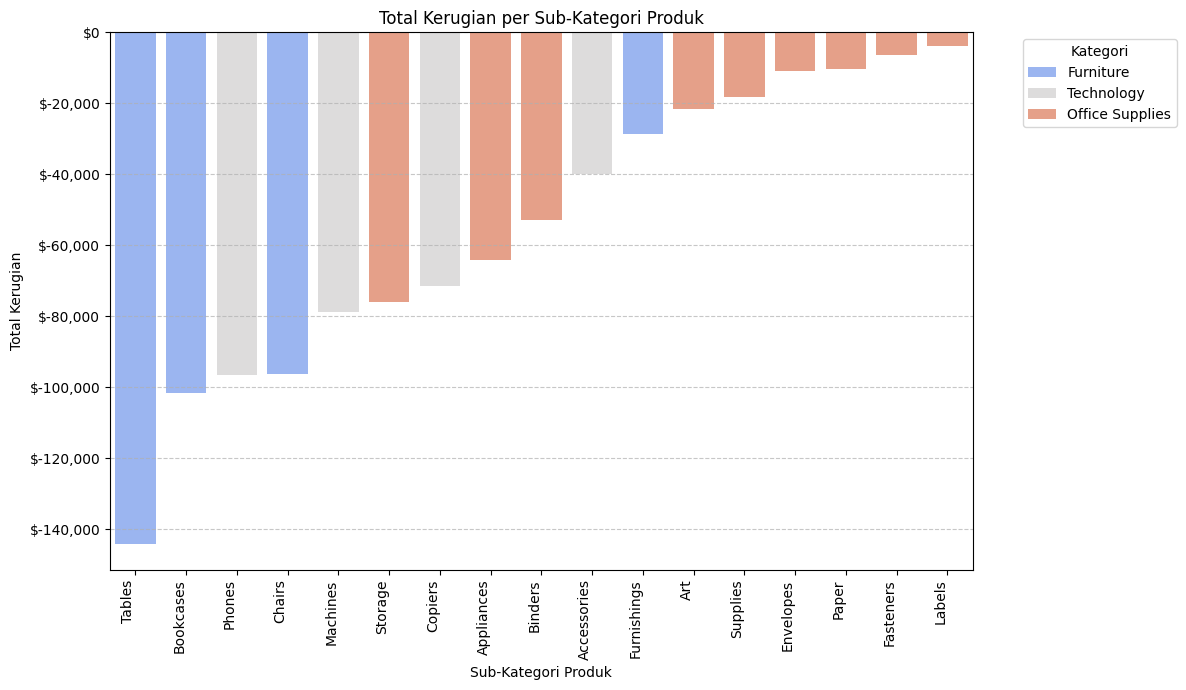

In [ ]:
#Breakdown ke Sub Category
loss_subcategory = (
    loss_df
    .groupby(["Category", "Sub-Category"])
    .agg(
        Total_Loss=("Profit","sum"),
        Transactions=("Order ID","count")
    )
    .sort_values("Total_Loss")
)

display(loss_subcategory.style.format({'Total_Loss': '${:,.2f}'}))

# Visualisasi kerugian berdasarkan Sub Kategori
fig = plt.figure(figsize=(12, 7))
sns.barplot(x=loss_subcategory.index.get_level_values(1), y='Total_Loss', hue=loss_subcategory.index.get_level_values(0), data=loss_subcategory, palette='coolwarm', dodge=False)
plt.title('Total Kerugian per Sub-Kategori Produk')
plt.xlabel('Sub-Kategori Produk')
plt.ylabel('Total Kerugian')
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
formatter = FuncFormatter(currency_formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.legend(title='Kategori', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
#Breakdown ke Product
loss_product = (
    loss_df
    .groupby("Product Name")
    .agg(
        Total_Loss=("Profit","sum"),
        Transactions=("Order ID","count")
    )
    .sort_values("Total_Loss")
)

loss_product.head(20)

,Total_Loss,Transactions
Product Name,,
Cubify CubeX 3D Printer Double Head Print,-9239.9692,2
"Hoover Stove, White",-6941.3190,5
GBC DocuBind P400 Electric Binding System,-6859.3896,3
"Apple Smart Phone, Full Size",-6561.1119,11
"Motorola Smart Phone, Cordless",-6511.9380,8
"Samsung Smart Phone, Cordless",-6191.9100,7
"Cisco Smart Phone, Cordless",-5516.2600,12
"Nokia Smart Phone, Full Size",-5286.4945,13
Lexmark MX611dhe Monochrome Laser Printer,-5269.9690,3


In [ ]:
#Breakdown ke Customer
#mencari customer mana yang sering dapat diskon
loss_customer = (
    loss_df
    .groupby("Customer Name")
    .agg(
        Total_Loss=("Profit","sum"),
        Transactions=("Order ID","count")
    )
    .sort_values("Total_Loss")
)

loss_customer.head(10)

,Total_Loss,Transactions
Customer Name,,
Cindy Stewart,-7593.64490,6
Denise Monton,-6794.35590,19
Grant Thornton,-5197.39716,17
Luke Foster,-5090.96350,26
Saphhira Shifley,-5053.77004,19
Natalie Fritzler,-5009.43560,30
Michelle Tran,-4978.30350,26
Skye Norling,-4820.63940,23
Zuschuss Carroll,-4412.43580,33


oke disini US menjadi negara yang banyak membuat rugi perusahaan

# **Analisis 3- Diskon**

In [ ]:
#menacari tahu bentuk data diskonnya.
print(df["Discount"].describe())

print(df["Discount"].unique())

count    51290.000000
mean         0.142908
std          0.212280
min          0.000000
25%          0.000000
50%          0.000000
75%          0.200000
max          0.850000
Name: Discount, dtype: float64
[0.    0.15  0.1   0.35  0.6   0.65  0.7   0.5   0.3   0.2   0.4   0.8
 0.85  0.45  0.27  0.17  0.37  0.47  0.25  0.57  0.55  0.07  0.002 0.602
 0.202 0.402 0.32 ]


,Discount,Transaction,Discount_Percentage
0,0.000,29009,0%
1,0.002,461,0%
2,0.070,150,7%
3,0.100,4068,10%
4,0.150,541,15%
5,0.170,735,17%
6,0.200,4998,20%
7,0.202,41,20%
8,0.250,198,25%
9,0.270,388,27%


/tmp/ipykernel_68392/3569431662.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Discount_Percentage', y='Transaction', data=discount_dist, palette='crest')


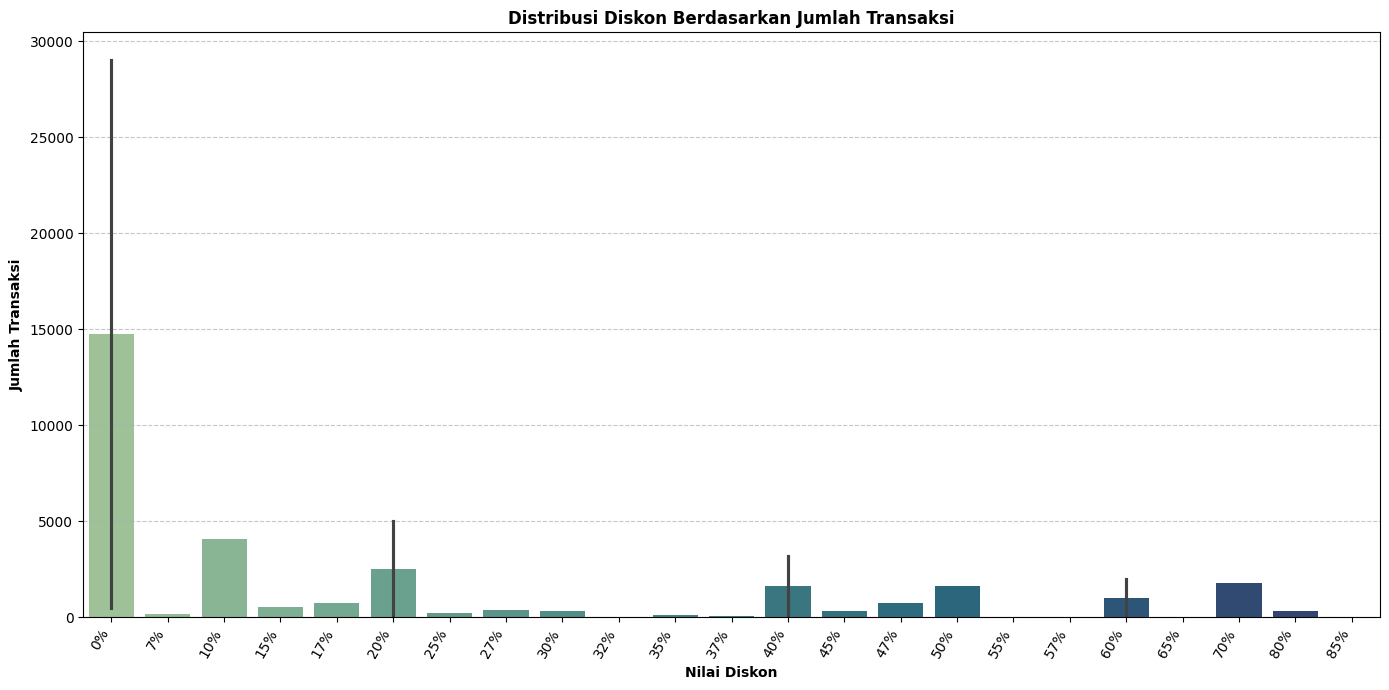

In [ ]:
#Distribusi Discount
#mencari tahu apakah mayoritas transaksi memang menggunakan diskon.
discount_dist = (
    df["Discount"]
      .value_counts()
      .sort_index()
      .reset_index()
)

discount_dist.columns = ["Discount", "Transaction"]

# Convert 'Discount' to percentage string BEFORE plotting
discount_dist['Discount_Percentage'] = discount_dist['Discount'].apply(lambda x: f'{x:.0%}')

display(discount_dist)

# Visualisasi Distribusi Discount
fig = plt.figure(figsize=(14, 7))
sns.barplot(x='Discount_Percentage', y='Transaction', data=discount_dist, palette='crest')
plt.title('Distribusi Diskon Berdasarkan Jumlah Transaksi', fontweight='bold')
plt.xlabel('Nilai Diskon', fontweight='bold')
plt.ylabel('Jumlah Transaksi', fontweight='bold')

# The FuncFormatter is no longer needed as labels are pre-formatted
# plt.gca().xaxis.set_major_formatter(formatter)

plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#Discount vs Average Profit
discount_profit = (
    df.groupby("Discount")
      .agg(
          Avg_Profit=("Profit","mean"),
          Total_Profit=("Profit","sum"),
          Avg_Sales=("Sales","mean"),
          Transactions=("Order ID","count")
      )
      .reset_index()
)

display(discount_profit)

,Discount,Avg_Profit,Total_Profit,Avg_Sales,Transactions
0,0.000,61.039514,1.770695e+06,241.053949,29009
1,0.002,125.762649,5.797658e+04,567.017354,461
2,0.070,140.990022,2.114850e+04,810.800000,150
3,0.100,63.683426,2.590642e+05,388.303343,4068
4,0.150,50.602409,2.737590e+04,565.687616,541
5,0.170,38.317107,2.816307e+04,336.604082,735
6,0.200,23.552594,1.177159e+05,240.867347,4998
7,0.202,-14.518847,-5.952727e+02,395.439024,41
8,0.250,4.043371,8.005875e+02,444.762626,198
9,0.270,-4.317213,-1.675079e+03,230.286082,388


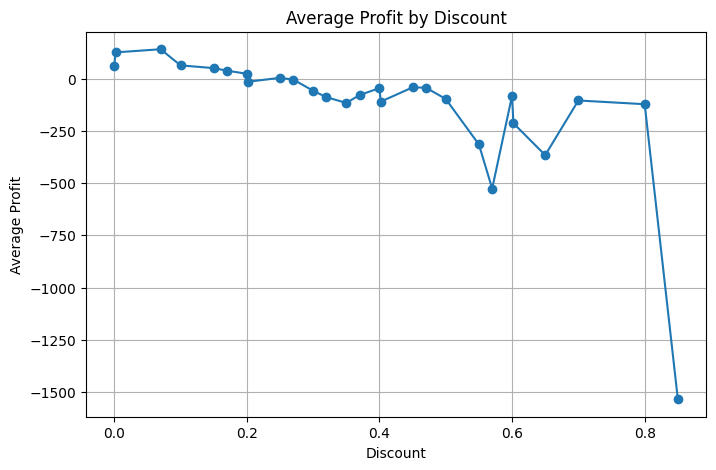

In [ ]:
discount_profit = (
    df.groupby("Discount")
      .agg(
          Avg_Profit=("Profit","mean"),
          Total_Profit=("Profit","sum"),
          Avg_Sales=("Sales","mean"),
          Transactions=("Order ID","count")
      )
      .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    discount_profit["Discount"],
    discount_profit["Avg_Profit"],
    marker="o"
)

plt.title("Average Profit by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.grid(True)

plt.show()

# Kesimpulan nya mulai dari diskon 30% ke atas perusahaan mulai mengalami kerugian

In [ ]:
#Korelasi Discount dan Profit
correlation = df["Discount"].corr(df["Profit"])

print(correlation)

-0.3164901718272714


Kekuatan -0.3: Angka ini berada di kisaran 0.3, yang berarti hubungannya tidak mutlak kuat, namun cukup nyata untuk diperhatikan. Diskon bukan satu-satunya penentu kerugian (ada faktor lain seperti ongkos kirim, kategori produk, atau harga dasar), tetapi diskon memiliki tren pola yang jelas menurunkan keuntungan.

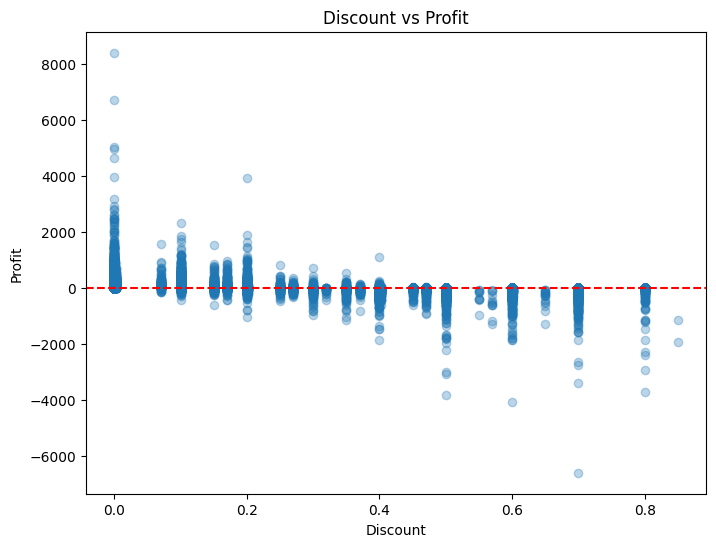

In [ ]:
#scatter plot
#apakah titik rugi terkumpul pada diskon tinggi?
#apakah masih ada transaksi untung pada diskon tinggi?

plt.figure(figsize=(8,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.3
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Discount vs Profit")

plt.xlabel("Discount")

plt.ylabel("Profit")

plt.show()

In [ ]:
#Discount Group
#Agar lebih mudah dibaca, buat bucket.


bins = [-0.01,0,0.1,0.2,0.3,0.4,1]

labels = [
    "0%",
    "0-10%",
    "10-20%",
    "20-30%",
    "30-40%",
    "40%+"
]

df["Discount_Group"] = pd.cut(
    df["Discount"],
    bins=bins,
    labels=labels
)

/tmp/ipykernel_68392/375463942.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Discount_Group")


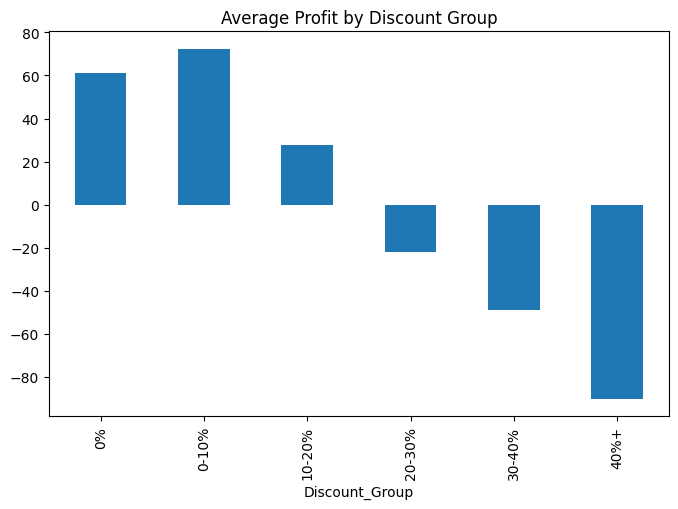

In [ ]:
discount_summary = (
    df.groupby("Discount_Group")
      .agg(
          Avg_Profit=("Profit","mean"),
          Total_Profit=("Profit","sum"),
          Sales=("Sales","sum"),
          Transactions=("Order ID","count")
      )
)



discount_summary["Avg_Profit"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Profit by Discount Group")
plt.show()

/tmp/ipykernel_68392/2232451522.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Category","Discount_Group"])


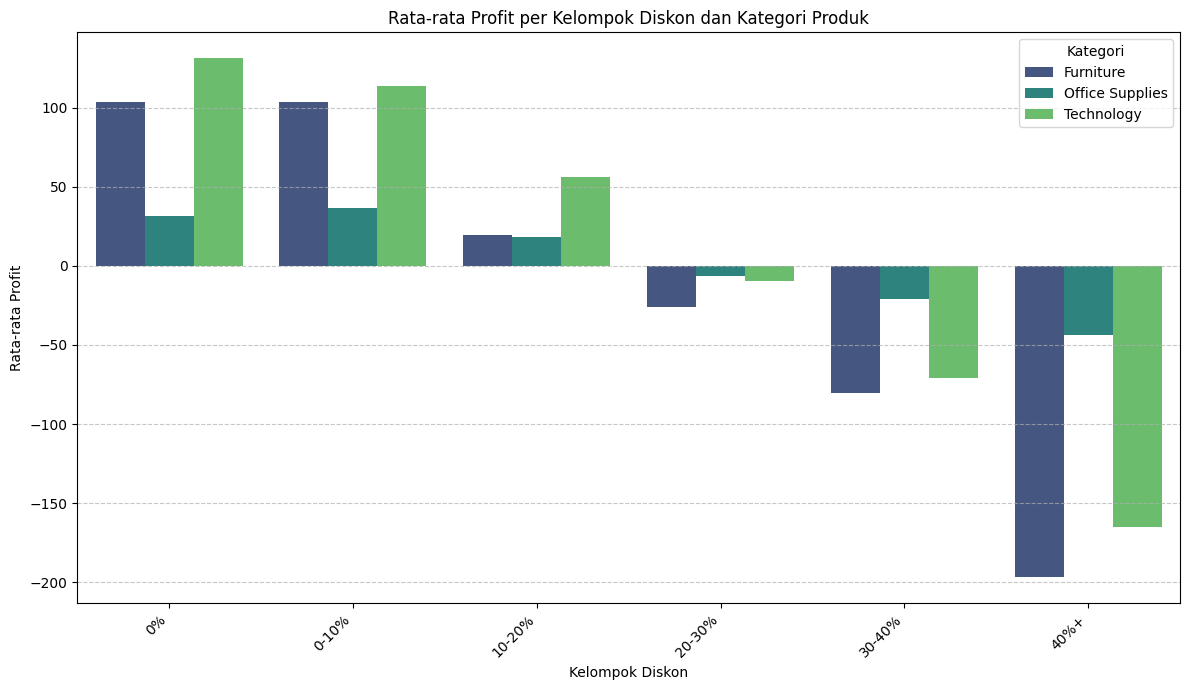

In [ ]:
#Cross Analysis
#mencari tahu Kategori apa yang paling terdampak oleh diskon tinggi?

discount_category = (
    df.groupby(["Category","Discount_Group"])
      .agg(
          Avg_Profit=("Profit","mean"),
          Transactions=("Order ID","count")
      )
      .reset_index()
)

# Visualisasi rata-rata profit per kategori dan kelompok diskon
plt.figure(figsize=(12, 7))
sns.barplot(x='Discount_Group', y='Avg_Profit', hue='Category', data=discount_category, palette='viridis')
plt.title('Rata-rata Profit per Kelompok Diskon dan Kategori Produk')
plt.xlabel('Kelompok Diskon')
plt.ylabel('Rata-rata Profit')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Kategori')
plt.tight_layout()
plt.show()

In [ ]:
high_discount_loss = df[
    (df["Discount"] >= 0.3) &
    (df["Profit"] < 0)
]

top_products = (
    high_discount_loss.groupby("Product Name")
    .agg(
        Total_Loss=("Profit","sum"),
        Transactions=("Order ID","count")
    )
    .sort_values("Total_Loss")
)

top_products.head(20)

,Total_Loss,Transactions
Product Name,,
Cubify CubeX 3D Printer Double Head Print,-9239.9692,2
GBC DocuBind P400 Electric Binding System,-6859.3896,3
"Hoover Stove, White",-6714.5910,3
"Apple Smart Phone, Full Size",-6013.7130,8
"Motorola Smart Phone, Cordless",-5804.6760,4
"Samsung Smart Phone, Cordless",-5706.2700,5
Lexmark MX611dhe Monochrome Laser Printer,-5269.9690,3
"Cisco Smart Phone, Cordless",-5229.5800,11
GBC Ibimaster 500 Manual ProClick Binding System,-5098.5660,6


In [ ]:
product_name = "Cubify CubeX 3D Printer Double Head Print"
product_info = df[df["Product Name"] == product_name][["Sales", "Discount"]]

print(f"Informasi untuk produk: {product_name}")
display(product_info.style.format({'Sales': '${:,.2f}', 'Discount': '{:.2%}'}))

Informasi untuk produk: Cubify CubeX 3D Printer Double Head Print


,Sales,Discount
47070,"$1,800.00",70.00%
47074,"$4,500.00",70.00%
50999,"$4,800.00",20.00%


# **Analisis 4 — Shipping Cost Impact Analysis**

count    51290.000000
mean        26.375818
std         57.296810
min          0.002000
25%          2.610000
50%          7.790000
75%         24.450000
max        933.570000
Name: Shipping Cost, dtype: float64


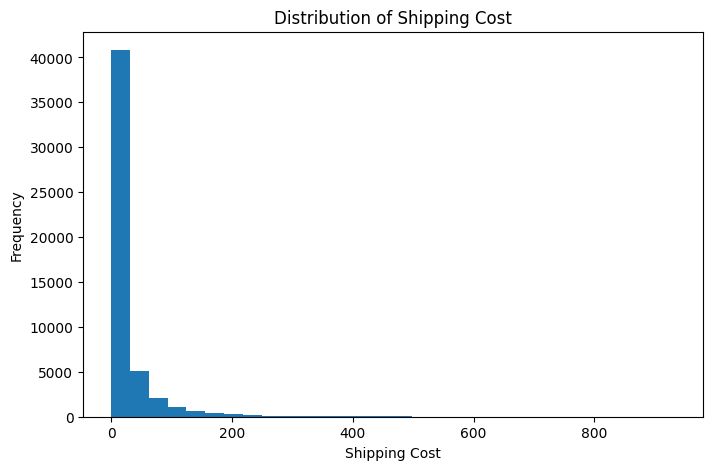

In [ ]:
#Pertama saya ingin tahu distribusi biaya kirim.
print(df["Shipping Cost"].describe())

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["Shipping Cost"],
    bins=30
)

plt.title("Distribution of Shipping Cost")

plt.xlabel("Shipping Cost")

plt.ylabel("Frequency")

plt.show()

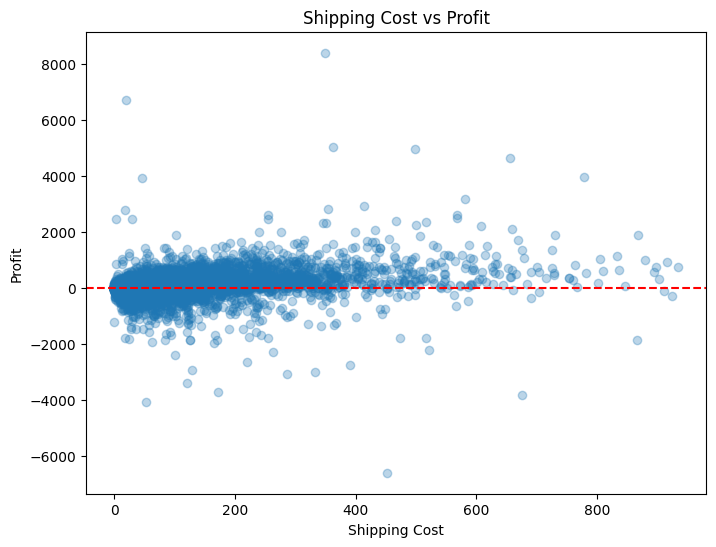

In [ ]:
#Shipping Cost vs Profit

plt.figure(figsize=(8,6))

plt.scatter(
    df["Shipping Cost"],
    df["Profit"],
    alpha=0.3
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Shipping Cost vs Profit")

plt.xlabel("Shipping Cost")

plt.ylabel("Profit")

plt.show()

In [ ]:
#Korelasi
correlation = df["Shipping Cost"].corr(df["Profit"])

print(correlation)

0.35444082723434184


In [ ]:
#Shipping Cost Ratio
#berapa persen Sales habis untuk shipping.

df["Shipping_Cost_Ratio"] = (
    df["Shipping Cost"] /
    df["Sales"]
)

In [ ]:
#Cari Transaksi Tidak Efisien

inefficient_shipping = df[
    df["Shipping_Cost_Ratio"] > 0.30
]

inefficient_shipping.head()

print("Jumlah transaksi:", len(inefficient_shipping))

print("Profit rata-rata:")

print(
    inefficient_shipping["Profit"].mean()
)

Jumlah transaksi: 1364
Profit rata-rata:
33.01808563049853


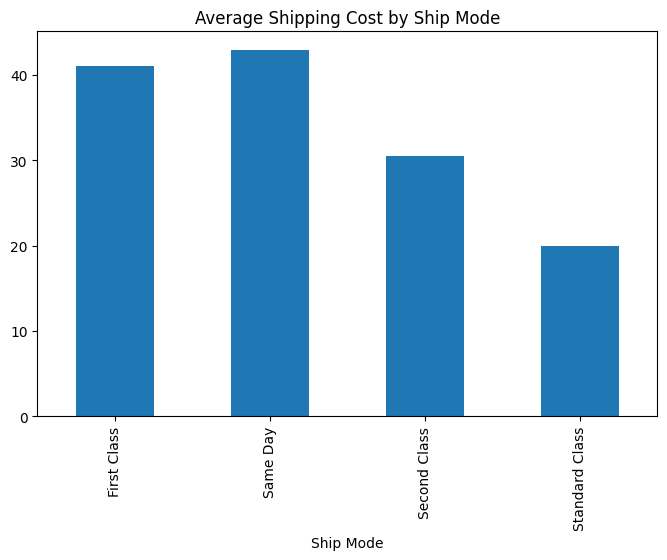

In [ ]:
#Shipping Cost per Ship Mode

shipmode = (
    df.groupby("Ship Mode")
      .agg(
          Avg_Shipping=("Shipping Cost","mean"),
          Avg_Profit=("Profit","mean"),
          Total_Sales=("Sales","sum"),
          Transactions=("Order ID","count")
      )
)

shipmode

shipmode["Avg_Shipping"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Shipping Cost by Ship Mode")

plt.show()

In [ ]:
#Shipping Cost per Category

shipping_category = (
    df.groupby("Category")
      .agg(
          Avg_Shipping=("Shipping Cost","mean"),
          Avg_Profit=("Profit","mean")
      )
)

shipping_category

,Avg_Shipping,Avg_Profit
Category,,
Furniture,44.584799,28.878567
Office Supplies,12.964805,16.578961
Technology,49.999791,65.454958


In [ ]:
#Shipping Cost per Country

shipping_country = (
    df.groupby("Country")
      .agg(
          Avg_Shipping=("Shipping Cost","mean"),
          Avg_Profit=("Profit","mean")
      )
      .sort_values("Avg_Shipping", ascending=False)
)

shipping_country.head(20)

,Avg_Shipping,Avg_Profit
Country,,
Taiwan,155.660714,129.900000
Chad,148.970000,45.000000
Lesotho,135.650000,233.035000
Montenegro,93.937500,321.690000
Slovenia,61.220000,196.680000
Republic of the Congo,59.303333,46.790000
Central African Republic,57.625714,66.934286
Namibia,50.370000,81.883333
Bangladesh,46.402883,119.207914


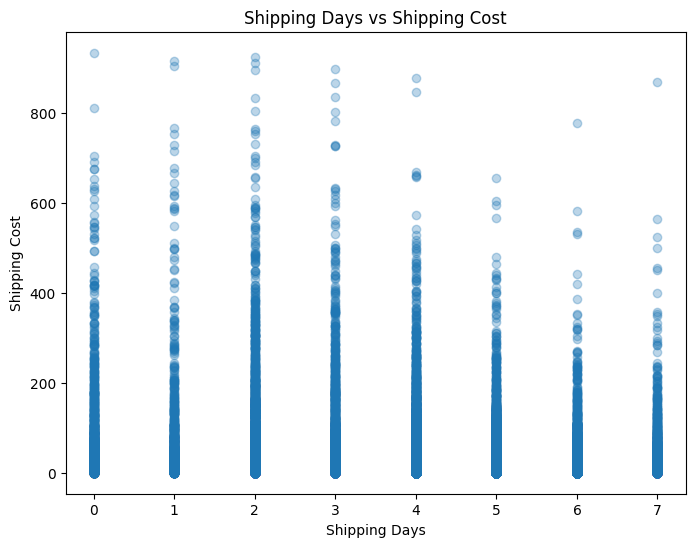

In [ ]:
import matplotlib.pyplot as plt

#Shipping Days vs Shipping Cost

plt.figure(figsize=(8,6))

plt.scatter(
    superstore["Shipping_Days"],
    superstore["Shipping Cost"],
    alpha=0.3
)

plt.title("Shipping Days vs Shipping Cost")

plt.xlabel("Shipping Days")

plt.ylabel("Shipping Cost")

plt.show()

In [ ]:
#Shipping Cost pada Transaksi Rugi

df["Loss_Flag"] = np.where(
    df["Profit"] < 0,
    "Loss",
    "Profit"
)

loss_shipping = (
    superstore.groupby("Loss_Flag")
      .agg(
          Avg_Shipping=("Shipping Cost","mean"),
          Avg_Profit=("Profit","mean")
      )
)

loss_shipping

,Avg_Shipping,Avg_Profit
Loss_Flag,,
Loss,21.234778,-73.393348
Profit,28.040227,61.634838


# **4.1 Seasonal Trend Analysis**

,Month Number,Month,Total_Sales,Total_Profit,Total_Orders
0,1,January,675141,73535.38454,1271
1,2,February,543768,70932.19922,1104
2,3,March,770519,94087.52096,1555
3,4,April,698603,73513.63124,1506
4,5,May,904061,104509.78428,1897
5,6,June,1269751,147079.41684,2662
6,7,July,749423,78070.09172,1561
7,8,August,1293852,151854.10972,2500
8,9,September,1437432,170438.18316,3021
9,10,October,1168220,157269.35838,2290


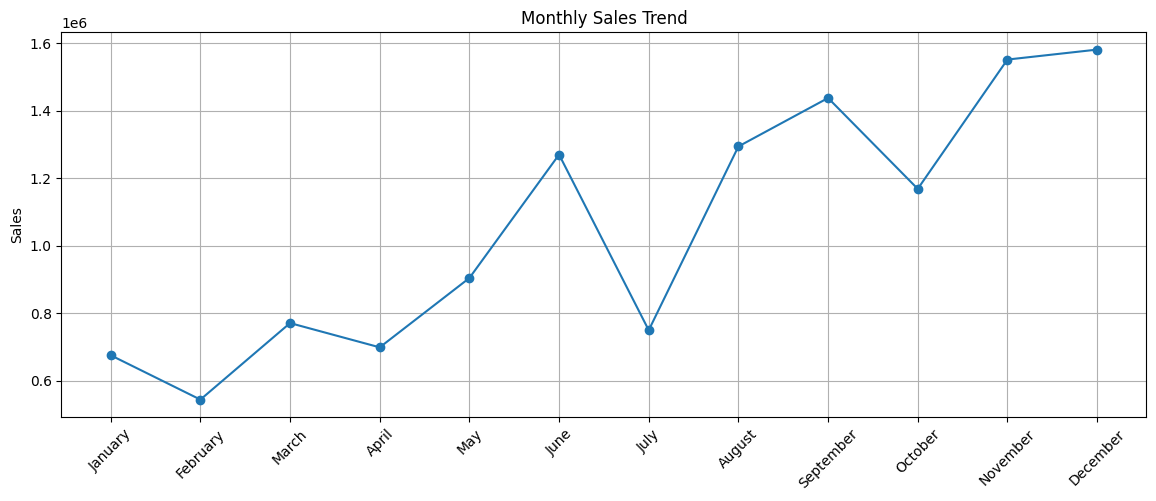

In [ ]:


df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Month'] = df['Order Date'].dt.month_name()
df['Month Number'] = df['Order Date'].dt.month

monthly_sales = (
    df.groupby(['Month Number','Month'])
      .agg(
          Total_Sales=('Sales','sum'),
          Total_Profit=('Profit','sum'),
          Total_Orders=('Order ID','nunique')
      )
      .reset_index()
      .sort_values('Month Number')
)

display(monthly_sales)

plt.figure(figsize=(14,5))
plt.plot(monthly_sales['Month'], monthly_sales['Total_Sales'], marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

# **4.2 segmen analis**

,Sales,Profit,Orders,Customers,Quantity
Segment,,,,,
Consumer,6508141,749239.78206,13104,2509,92157
Corporate,3824808,441208.32866,7673,1457,53565
Home Office,2309956,277009.18056,4687,907,32590


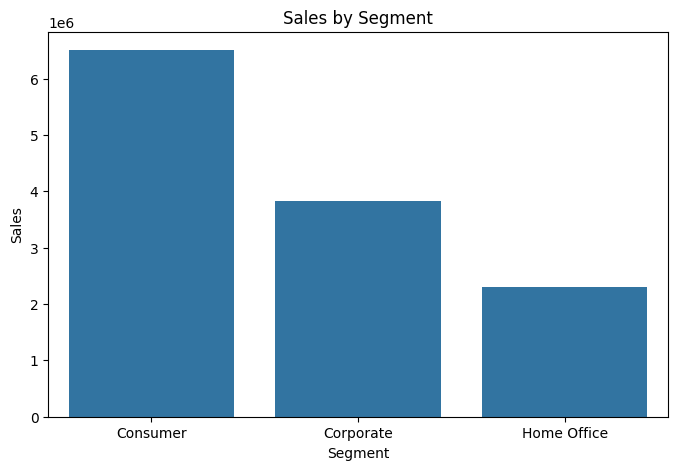

In [ ]:
segment_analysis = (
    df.groupby('Segment')
      .agg(
          Sales=('Sales','sum'),
          Profit=('Profit','sum'),
          Orders=('Order ID','nunique'),
          Customers=('Customer ID','nunique'),
          Quantity=('Quantity','sum')
      )
      .sort_values('Sales',ascending=False)
)

display(segment_analysis)

plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_analysis.reset_index(),
    x='Segment',
    y='Sales'
)

plt.title("Sales by Segment")
plt.show()

# **4.3 order priority**

,Sales,Profit,Shipping_Cost,Orders
Order Priority,,,,
Medium,7281105,864203.76262,18.442320,14484
High,3807699,420373.51340,32.871806,7767
Critical,986258,124224.16428,59.721245,1967
Low,567843,58655.85098,27.076355,1212


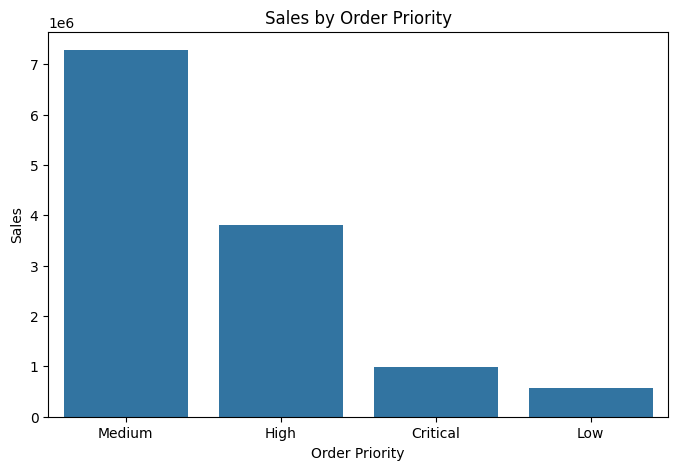

In [ ]:
priority = (
    df.groupby("Order Priority")
      .agg(
          Sales=('Sales','sum'),
          Profit=('Profit','sum'),
          Shipping_Cost=('Shipping Cost','mean'),
          Orders=('Order ID','nunique')
      )
      .sort_values('Sales',ascending=False)
)

display(priority)

plt.figure(figsize=(8,5))

sns.barplot(
    data=priority.reset_index(),
    x="Order Priority",
    y="Sales"
)

plt.title("Sales by Order Priority")
plt.show()

# **4.4 ship mode**

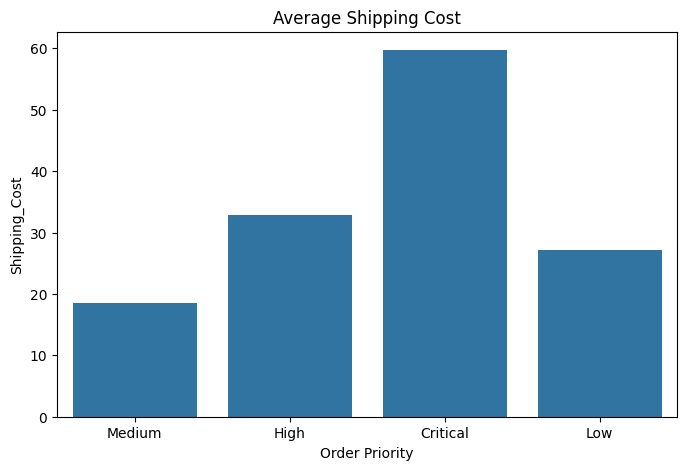

,Sales,Profit,Shipping_Cost,Orders
Ship Mode,,,,
Standard Class,7578889,890596.02120,19.971654,15154
Second Class,2565747,292583.52708,30.469666,5119
First Class,1831067,208104.67520,41.052970,3821
Same Day,667202,76173.06780,42.937325,1347


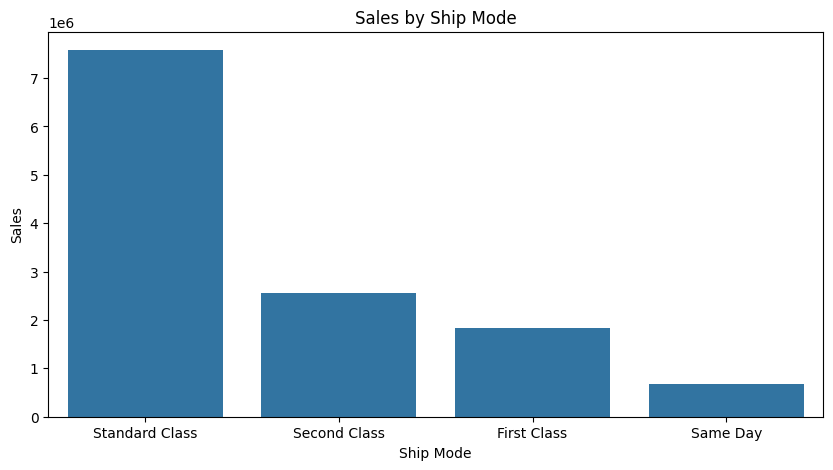

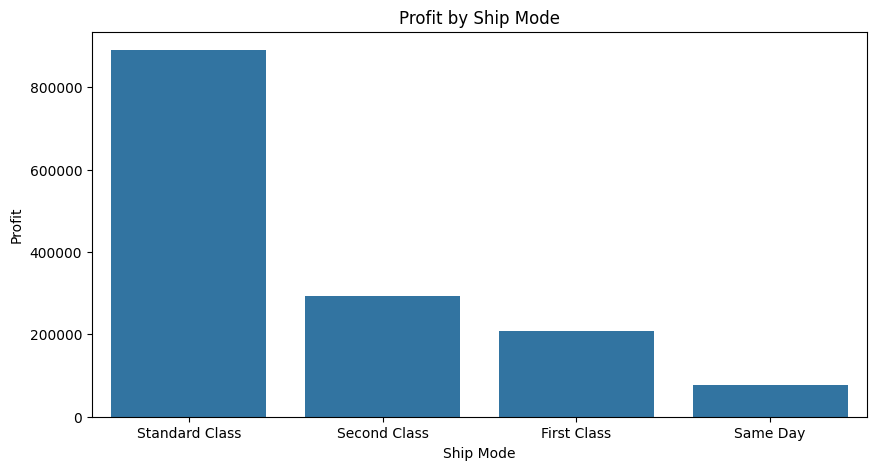

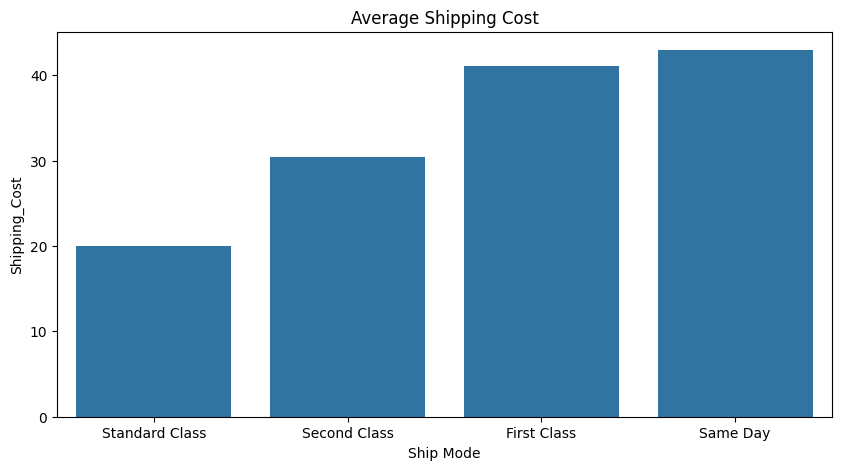

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=priority.reset_index(),
    x='Order Priority',
    y='Shipping_Cost'
)

plt.title("Average Shipping Cost")
plt.show()



ship_mode = (
    df.groupby("Ship Mode")
      .agg(
          Sales=('Sales','sum'),
          Profit=('Profit','sum'),
          Shipping_Cost=('Shipping Cost','mean'),
          Orders=('Order ID','nunique')
      )
      .sort_values('Sales',ascending=False)
)

display(ship_mode)

plt.figure(figsize=(10,5))

sns.barplot(
    data=ship_mode.reset_index(),
    x='Ship Mode',
    y='Sales'
)

plt.title("Sales by Ship Mode")
plt.show()

plt.figure(figsize=(10,5))

sns.barplot(
    data=ship_mode.reset_index(),
    x='Ship Mode',
    y='Profit'
)

plt.title("Profit by Ship Mode")
plt.show()

plt.figure(figsize=(10,5))

sns.barplot(
    data=ship_mode.reset_index(),
    x='Ship Mode',
    y='Shipping_Cost'
)

plt.title("Average Shipping Cost")
plt.show()



# **Analisis 5 — Geographic Intelligence**

In [ ]:
#Country Performance
#melihat performa tiap negara.

country_summary = (
    df.groupby("Country")
      .agg(
          Total_Sales=("Sales","sum"),
          Total_Profit=("Profit","sum"),
          Avg_Discount=("Discount","mean"),
          Avg_Shipping=("Shipping Cost","mean"),
          Orders=("Order ID","nunique")
      )
      .reset_index() # Add .reset_index() here to make 'Country' a column
      .sort_values("Total_Profit", ascending=False)
)

country_summary

#Insight yang dicari

#Jangan hanya melihat siapa yang paling untung.

#Cari juga:

#Negara dengan Sales tinggi tapi Profit rendah
#Negara dengan Sales rendah tapi Profit tinggi

#Karena itu menunjukkan efisiensi.

,Country,Total_Sales,Total_Profit,Avg_Discount,Avg_Shipping,Orders
139,United States,2297354,286397.0217,0.156203,23.831678,5009
26,China,700591,150683.0850,0.014309,41.998415,925
57,India,589664,129071.8350,0.017685,39.730367,785
138,United Kingdom,528570,111900.1500,0.065707,32.810945,775
44,France,858930,109029.0030,0.072285,33.741709,1222
...,...,...,...,...,...,...
96,Pakistan,58873,-22446.6480,0.444578,23.426064,123
54,Honduras,90137,-29482.3714,0.406833,13.564498,349
90,Netherlands,77520,-41070.0750,0.481839,20.702874,204
94,Nigeria,54347,-80750.7180,0.700000,6.832166,410


In [ ]:
#Tambahkan Profit Margin

country_summary["Profit_Margin"] = (
    country_summary["Total_Profit"] /
    country_summary["Total_Sales"]
)

country_summary.sort_values(
    "Profit_Margin",
    ascending=False
)

,Country,Total_Sales,Total_Profit,Avg_Discount,Avg_Shipping,Orders,Profit_Margin
5,Armenia,156,69.090,0.0,4.500000,2,0.442885
80,Mauritania,4020,1675.950,0.0,44.115000,8,0.416903
40,Eritrea,188,76.200,0.0,4.275000,1,0.405319
114,Slovenia,1469,590.040,0.0,61.220000,2,0.401661
19,Burundi,268,103.080,0.0,9.255000,2,0.384627
...,...,...,...,...,...,...,...
94,Nigeria,54347,-80750.718,0.7,6.832166,410,-1.485836
135,Uganda,1625,-2426.085,0.7,4.483514,19,-1.492975
144,Yemen,2464,-3706.458,0.7,9.554333,11,-1.504244
67,Kazakhstan,4602,-7099.896,0.7,4.972970,53,-1.542785


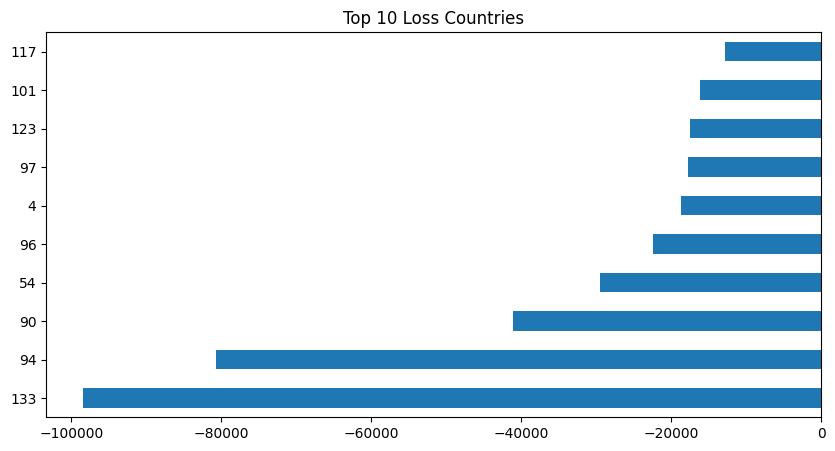

In [ ]:
#Bottom 10 Profit Country

bottom_profit = (
    country_summary
    .sort_values("Total_Profit")
    .head(10)
)

bottom_profit

bottom_profit["Total_Profit"].plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Top 10 Loss Countries")

plt.show()

In [ ]:
# country_summary
country_summary = (
    superstore.groupby("Country")
    .agg(
        Total_Sales=("Sales","sum"),
        Total_Profit=("Profit","sum"),
        Total_Customers=("Customer ID","nunique")
    )
    .reset_index()
)

country_summary["Profit_Margin"] = (
    country_summary["Total_Profit"] /
    country_summary["Total_Sales"]
)

fig = px.scatter(
    country_summary,
    x="Total_Sales",
    y="Total_Profit",
    size="Total_Customers",
    color="Profit_Margin",
    hover_name="Country",
    title="Country Performance Matrix"
)

fig.show()

In [ ]:
#Discount by Country

country_discount = (
    df.groupby("Country")
      .agg(
          Avg_Discount=("Discount","mean"),
          Profit=("Profit","sum")
      )
      .sort_values(
          "Avg_Discount",
          ascending=False
      )
)

country_discount.head(20)

,Avg_Discount,Profit
Country,,
Zimbabwe,0.700000,-5428.78500
United Arab Emirates,0.700000,-1036.86000
Lithuania,0.700000,-8966.11800
Yemen,0.700000,-3706.45800
Uganda,0.700000,-2426.08500
Nigeria,0.700000,-80750.71800
Turkmenistan,0.700000,-3302.70900
Kazakhstan,0.700000,-7099.89600
Tajikistan,0.700000,-262.86600


# **Analisis 6 — Customer Profitability Analysis**

In [ ]:

#Customer Summary
#Pertama kita agregasi seluruh transaksi menjadi level customer.


customer = (
    df.groupby(["Customer ID", "Customer Name"])
      .agg(
          Total_Sales=("Sales","sum"),
          Total_Profit=("Profit","sum"),
          Total_Order=("Order ID","nunique"),
          Total_Quantity=("Quantity","sum"),
          Avg_Discount=("Discount","mean"),
          Avg_Shipping=("Shipping Cost","mean")
      )
      .reset_index()
)

customer.head()
#Top Customer

top_customer = customer.sort_values(
    "Total_Profit",
    ascending=False
)

top_customer.head(10)


,Customer ID,Customer Name,Total_Sales,Total_Profit,Total_Order,Total_Quantity,Avg_Discount,Avg_Shipping
4564,TC-209804,Tamara Chand,19050,8981.3239,5,42,0.116667,39.417500
3816,RB-193604,Raymond Buch,15117,6976.0959,6,71,0.094444,11.382252
4137,SC-200954,Sanjit Chand,14145,5757.4119,9,87,0.063636,50.822273
2015,HL-150404,Hunter Lopez,12875,5622.4292,6,50,0.018182,48.724545
37,AB-101054,Adrian Barton,14476,5444.8055,10,73,0.240000,47.269500
4359,SP-209202,Susan Pistek,16566,4974.5130,12,107,0.028333,49.255333
4487,TA-213854,Tom Ashbrook,14596,4703.7883,4,36,0.080000,56.857000
749,CA-127751,Cynthia Arntzen,11493,4045.8780,5,42,0.009091,62.707273
3649,PJ-188352,Patrick Jones,8509,3986.0040,3,26,0.080000,186.456000
969,CM-123854,Christopher Martinez,8953,3899.8904,4,34,0.120000,85.296000


In [ ]:
#Worst Customer

worst_customer = customer.sort_values(
    "Total_Profit"
)

worst_customer.head(20)

,Customer ID,Customer Name,Total_Sales,Total_Profit,Total_Order,Total_Quantity,Avg_Discount,Avg_Shipping
1085,CS-125054,Cindy Stewart,5691,-6626.38950,6,40,0.200000,66.841111
1380,DM-33452,Denise Monton,4664,-5377.68000,3,29,0.500000,24.833333
1908,GT-146354,Grant Thornton,9351,-4108.65890,3,26,0.250000,128.223333
4388,SS-201402,Saphhira Shifley,5653,-3957.13800,5,41,0.320000,50.093000
2823,LF-171854,Luke Foster,3931,-3583.97700,7,69,0.318750,23.871875
4370,SR-204254,Sharelle Roach,3234,-3333.91440,5,34,0.366667,18.627778
1981,HG-149654,Henry Goldwyn,3250,-2797.96350,12,68,0.170588,15.507059
4320,SN-205601,Skye Norling,6795,-2597.13000,6,47,0.150000,65.643000
3337,MT-80702,Michelle Tran,2025,-2519.63400,4,31,0.466667,15.204444
2138,JC-61052,Julie Creighton,3855,-2470.73400,5,42,0.346154,43.910000


In [ ]:
#Customer Shipping Cost
customer_shipping = (
    customer
    .sort_values(
        "Avg_Shipping",
        ascending=False
    )
)

customer_shipping.head(20)

,Customer ID,Customer Name,Total_Sales,Total_Profit,Total_Order,Total_Quantity,Avg_Discount,Avg_Shipping
3959,RH-94951,Rick Hansen,2833,311.52000,1,8,0.000000,903.040000
4103,SC-102302,Scot Coram,1619,258.90000,1,10,0.000000,301.730000
3357,MW-182354,Mitch Willingham,5254,1665.51600,2,13,0.066667,252.180000
67,AB-6002,Ann Blume,4027,711.09000,2,10,0.000000,232.172000
4424,SV-108152,Stuart Van,4009,1187.94000,1,12,0.000000,194.383333
3649,PJ-188352,Patrick Jones,8509,3986.00400,3,26,0.080000,186.456000
2028,HM-49801,Henry MacAllister,4068,1559.73000,2,8,0.000000,180.773333
1997,HH-50101,Hilary Holden,1296,305.52000,1,12,0.050000,175.875000
225,AJ-107801,Anthony Jacobs,5821,988.01370,5,19,0.235000,169.655000
1693,EP-139153,Emily Phan,1686,706.06144,1,8,0.002000,169.505000


In [ ]:
customer["Profit_Margin"] = (
    customer["Total_Profit"] /
    customer["Total_Sales"]
)

margin_rank = customer.sort_values(
    "Profit_Margin",
    ascending=False
)

margin_rank.head(20)

,Customer ID,Customer Name,Total_Sales,Total_Profit,Total_Order,Total_Quantity,Avg_Discount,Avg_Shipping,Profit_Margin
3050,MD-73502,Maribeth Dona,26,13.2000,1,1,0.000000,0.530000,0.507692
1106,CS-24901,Cindy Schnelling,14,7.0500,1,1,0.000000,1.890000,0.503571
933,CL-18902,Carl Ludwig,53,26.6400,1,1,0.000000,5.990000,0.502642
2694,KM-66601,Khloe Miller,19,9.4200,1,3,0.000000,0.765000,0.495789
2504,JS-159401,Joni Sundaresam,22,10.8600,1,2,0.000000,2.430000,0.493636
262,AM-7053,Anne McFarland,411,202.2600,1,2,0.000000,24.890000,0.492117
3994,RM-96751,Robert Marley,198,96.9900,1,1,0.000000,20.550000,0.489848
1485,DW-34802,Dianna Wilson,2469,1201.1100,2,9,0.000000,100.590000,0.486476
2026,HM-48601,Harry Marie,259,125.1900,2,2,0.000000,16.910000,0.483359
4560,TC-115352,Tracy Collins,405,194.5500,1,3,0.000000,24.485000,0.480370


# **Analisis 7 — Product Portfolio Analysis**


*   Produk apa yang menjadi "bintang" perusahaan?
*   Produk apa yang harus dipromosikan?
*   Produk apa yang harus dievaluasi atau bahkan dihentikan?







In [ ]:
#Product Summary

product = (
    df.groupby(["Product ID", "Product Name"])
      .agg(
          Category=("Category","first"),
          Sub_Category=("Sub-Category","first"),
          Total_Sales=("Sales","sum"),
          Total_Profit=("Profit","sum"),
          Total_Quantity=("Quantity","sum"),
          Avg_Discount=("Discount","mean"),
          Avg_Shipping=("Shipping Cost","mean"),
          Total_Order=("Order ID","nunique")
      )
      .reset_index()
)

product.head()

,Product ID,Product Name,Category,Sub_Category,Total_Sales,Total_Profit,Total_Quantity,Avg_Discount,Avg_Shipping,Total_Order
0,FUR-ADV-10000002,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings,159,60.390,3,0.0000,5.070000,2
1,FUR-ADV-10000108,"Advantus Clock, Erganomic",Furniture,Furnishings,350,3.360,7,0.0000,7.633333,3
2,FUR-ADV-10000183,"Advantus Photo Frame, Black",Furniture,Furnishings,975,-651.738,31,0.2375,12.502500,8
3,FUR-ADV-10000188,"Advantus Stacking Tray, Erganomic",Furniture,Furnishings,125,4.200,7,0.2600,3.306000,5
4,FUR-ADV-10000190,"Advantus Frame, Duo Pack",Furniture,Furnishings,222,104.460,2,0.0000,32.710000,1


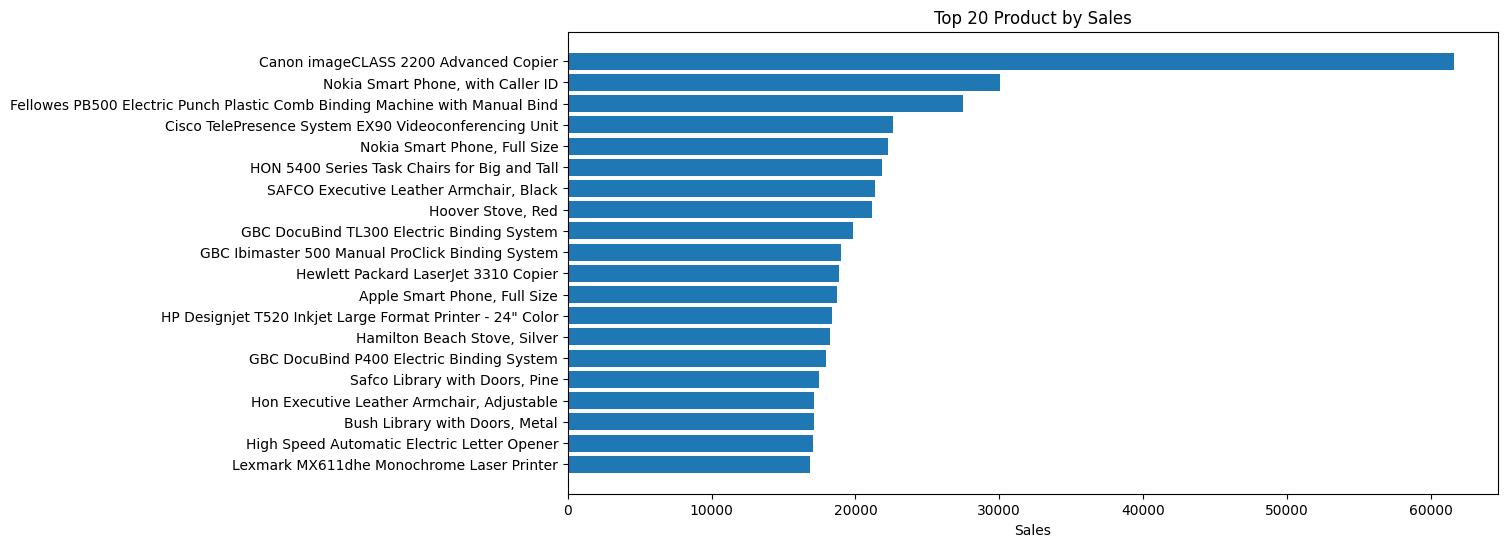

In [ ]:
#Top Product by Sales

top_sales = (
    product
    .sort_values("Total_Sales", ascending=False)
    .head(20)
)

top_sales

plt.figure(figsize=(12,6))

plt.barh(
    top_sales["Product Name"],
    top_sales["Total_Sales"]
)

plt.title("Top 20 Product by Sales")

plt.xlabel("Sales")

plt.gca().invert_yaxis()

plt.show()

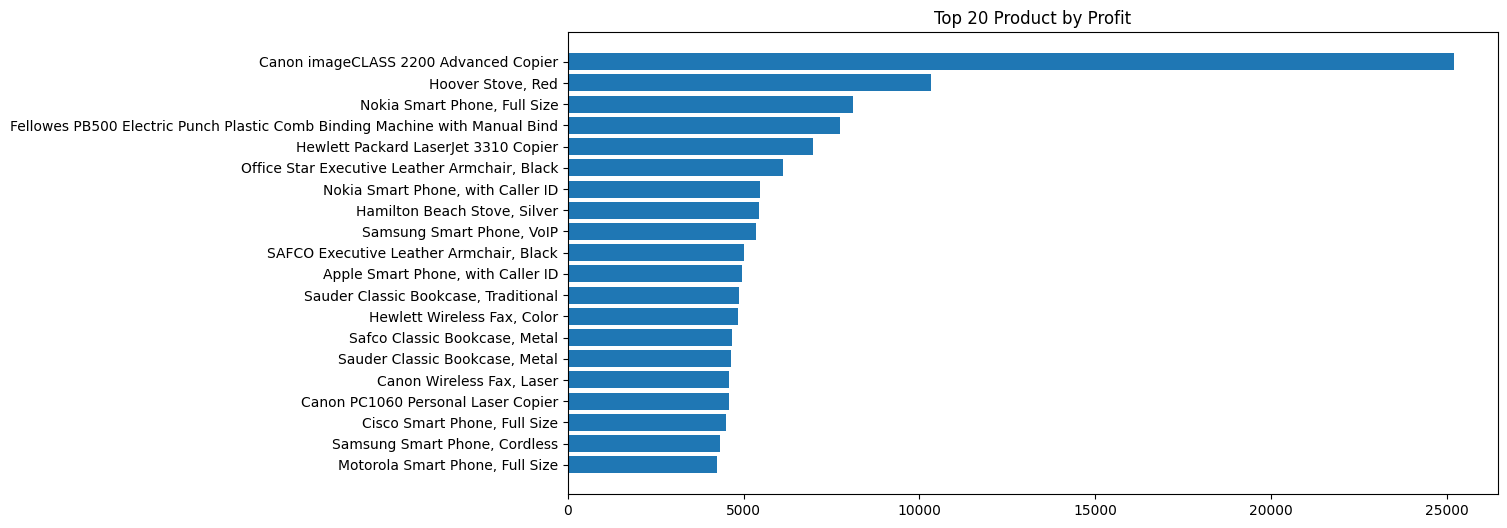

In [ ]:
#Top Product by Profit

top_profit = (
    product
    .sort_values("Total_Profit", ascending=False)
    .head(20)
)

top_profit

plt.figure(figsize=(12,6))

plt.barh(
    top_profit["Product Name"],
    top_profit["Total_Profit"]
)

plt.title("Top 20 Product by Profit")

plt.gca().invert_yaxis()

plt.show()

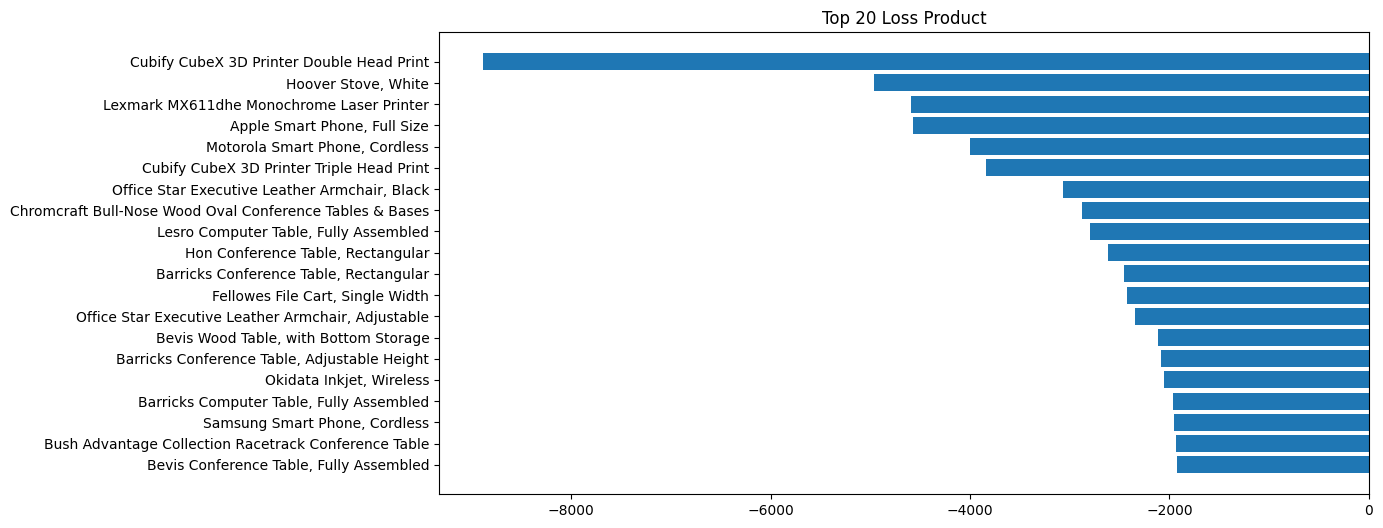

In [ ]:
#Worst Product

worst_product = (
    product
    .sort_values("Total_Profit")
    .head(20)
)

worst_product

plt.figure(figsize=(12,6))

plt.barh(
    worst_product["Product Name"],
    worst_product["Total_Profit"]
)

plt.title("Top 20 Loss Product")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
#Temukan Problem Product

sales_threshold = product["Total_Sales"].quantile(0.75)

problem_product = product[
    (product["Total_Sales"] >= sales_threshold) &
    (product["Total_Profit"] < 0)
]

problem_product

,Product ID,Product Name,Category,Sub_Category,Total_Sales,Total_Profit,Total_Quantity,Avg_Discount,Avg_Shipping,Total_Order
31,FUR-BAR-10003532,"Barricks Conference Table, Rectangular",Furniture,Tables,3076,-2460.810,9,0.350000,218.005000,2
52,FUR-BO-10000034,"Safco Classic Bookcase, Pine",Furniture,Bookcases,1451,-659.250,5,0.366667,28.770000,3
54,FUR-BO-10000038,"Bush Library with Doors, Pine",Furniture,Bookcases,2633,-1667.736,18,0.300000,63.436000,4
64,FUR-BO-10000170,"Safco Library with Doors, Mobile",Furniture,Bookcases,4943,-274.974,14,0.100000,224.415000,2
79,FUR-BO-10000288,"Safco Classic Bookcase, Traditional",Furniture,Bookcases,8368,-131.535,20,0.040000,220.838000,5
...,...,...,...,...,...,...,...,...,...,...
10714,TEC-SAN-10004027,"SanDisk Memory Card, Bluetooth",Technology,Accessories,1664,-194.532,19,0.300000,17.995000,4
10723,TEC-SHA-10000306,"Sharp Copy Machine, Color",Technology,Copiers,2185,-266.400,12,0.175000,44.775000,4
10726,TEC-SHA-10000971,"Sharp Fax Machine, Color",Technology,Copiers,2732,-546.732,12,0.300000,65.655714,7
10732,TEC-SHA-10002034,"Sharp Personal Copier, Laser",Technology,Copiers,1872,-45.600,17,0.175000,53.397500,4


In [ ]:
#Discount Effect

problem_product.sort_values(
    "Avg_Discount",
    ascending=False
)

,Product ID,Product Name,Category,Sub_Category,Total_Sales,Total_Profit,Total_Quantity,Avg_Discount,Avg_Shipping,Total_Order
10149,TEC-PH-10000808,"Samsung Smart Phone, Cordless",Technology,Phones,1363,-1806.24000,8,0.600000,255.173000,1
2236,FUR-TA-10003887,"Hon Conference Table, Adjustable Height",Furniture,Tables,1478,-1404.04800,6,0.600000,49.694500,2
2776,OFF-AP-10003308,"KitchenAid Stove, Black",Office Supplies,Appliances,1367,-922.78800,9,0.600000,70.318500,2
778,FUR-CH-10002275,"Novimex Executive Leather Armchair, Adjustable",Furniture,Chairs,1473,-1694.59200,8,0.600000,93.640000,1
2543,OFF-AP-10000934,"Hamilton Beach Stove, Black",Office Supplies,Appliances,1950,-1121.68800,9,0.600000,40.570000,1
...,...,...,...,...,...,...,...,...,...,...
8343,TEC-AC-10000483,"SanDisk Memory Card, Bluetooth",Technology,Accessories,2609,-9.28800,24,0.025000,46.915000,8
3119,OFF-AR-10001461,"BIC Canvas, Water Color",Office Supplies,Art,2059,-25.52400,37,0.022222,37.297778,9
9034,TEC-CO-10000679,"Hewlett Personal Copier, High-Speed",Technology,Copiers,5760,-21.97320,41,0.021000,81.956000,10
484,FUR-BO-10004699,"Dania 3-Shelf Cabinet, Mobile",Furniture,Bookcases,2563,-28.79400,18,0.016667,38.961667,6


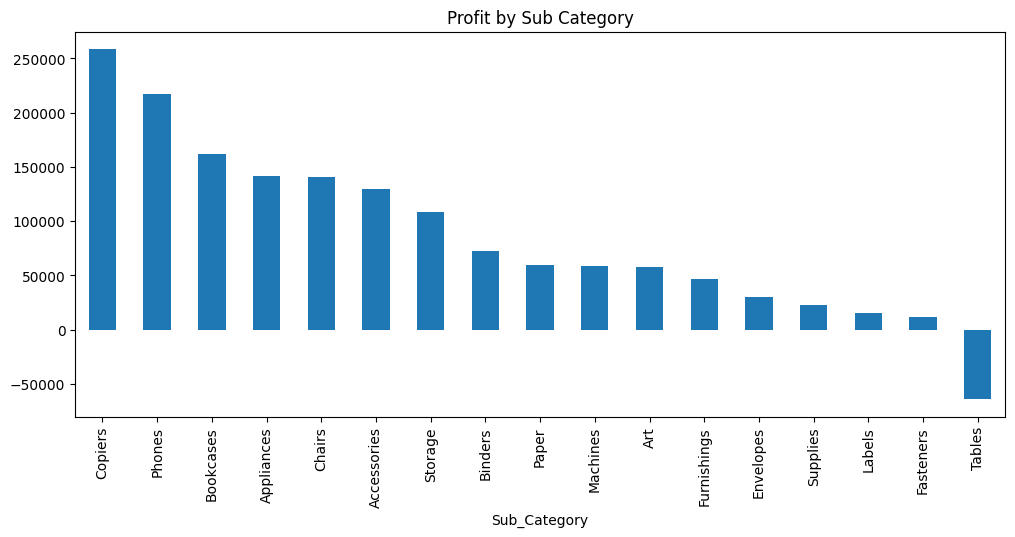

In [ ]:
#Sub Category Analysis

subcategory = (
    product
    .groupby("Sub_Category")
    .agg(
        Sales=("Total_Sales","sum"),
        Profit=("Total_Profit","sum"),
        Quantity=("Total_Quantity","sum")
    )
    .sort_values("Profit", ascending=False)
)

subcategory

subcategory["Profit"].plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Profit by Sub Category")

plt.show()

In [ ]:
customer["Profit_Margin"] = (
    customer["Total_Profit"] /
    customer["Total_Sales"]
)

product["Profit_Margin"] = (
    product["Total_Profit"] /
    product["Total_Sales"]
)

margin_rank = (
    product
    .sort_values("Profit_Margin", ascending=False)
)

margin_rank.head(20)

,Product ID,Product Name,Category,Sub_Category,Total_Sales,Total_Profit,Total_Quantity,Avg_Discount,Avg_Shipping,Total_Order,Profit_Margin
6279,OFF-PA-10000048,Xerox 20,Office Supplies,Paper,6,3.1104,1,0.0,0.610000,1,0.518400
7741,OFF-STO-10003395,"Stockwell Rubber Bands, Metal",Office Supplies,Fasteners,48,24.3900,3,0.0,2.953333,3,0.508125
5375,OFF-FA-10004374,"Accos Paper Clips, Bulk Pack",Office Supplies,Fasteners,28,14.1600,3,0.0,2.998000,1,0.505714
5728,OFF-KRA-10002170,"Kraft Business Envelopes, Security-Tint",Office Supplies,Envelopes,147,73.9800,9,0.0,2.524000,5,0.503265
6089,OFF-LA-10003498,Avery 475,Office Supplies,Labels,265,133.2000,18,0.0,7.130000,4,0.502642
8400,TEC-AC-10001047,"SanDisk Router, Erganomic",Technology,Accessories,169,84.7200,1,0.0,57.381000,1,0.501302
1429,FUR-FU-10002185,"Eldon Photo Frame, Durable",Furniture,Furnishings,110,55.1400,2,0.0,4.870000,1,0.501273
5444,OFF-FEL-10001796,"Fellowes Trays, Single Width",Office Supplies,Storage,401,200.9700,7,0.0,8.776000,5,0.501172
4486,OFF-EN-10000353,"Jiffy Mailers, with clear poly window",Office Supplies,Envelopes,203,101.7000,5,0.0,4.875000,2,0.500985
1170,FUR-FU-10000204,"Advantus Door Stop, Durable",Furniture,Furnishings,126,63.0900,3,0.0,14.340000,1,0.500714


# **Analisis - 8 Pareto Analysis (80/20 Rule)**

In [ ]:
#Profit per Product

pareto = (
    df.groupby(["Product ID","Product Name"])
      .agg(
          Total_Profit=("Profit","sum"),
          Total_Sales=("Sales","sum"),
          Total_Order=("Order ID","nunique")
      )
      .reset_index()
)

In [ ]:
#Urutkan berdasarkan Profit

pareto = pareto.sort_values(
    "Total_Profit",
    ascending=False
)

In [ ]:
#Hitung Cumulative Profit

pareto["Cumulative_Profit"] = (
    pareto["Total_Profit"].cumsum()
)

In [ ]:
#Hitung Persentase
total_profit = pareto["Total_Profit"].sum()

pareto["Cumulative_Percentage"] = (
    pareto["Cumulative_Profit"] /
    total_profit
) * 100

In [ ]:
#Ranking
pareto["Rank"] = range(1, len(pareto)+1)

In [ ]:
#Cari Titik 80%
pareto_80 = pareto[
    pareto["Cumulative_Percentage"] <= 80
]

pareto_80

,Product ID,Product Name,Total_Profit,Total_Sales,Total_Order,Cumulative_Profit,Cumulative_Percentage,Rank
9388,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,25199.9280,61600,5,2.519993e+04,1.717251,1
2882,OFF-AP-10004512,"Hoover Stove, Red",10345.5840,21148,7,3.554551e+04,2.422252,2
10646,TEC-PH-10004823,"Nokia Smart Phone, Full Size",8121.4800,22261,11,4.366699e+04,2.975691,3
4017,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390,27454,10,5.142003e+04,3.504022,4
9099,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,6983.8836,18840,8,5.840391e+04,3.979940,5
...,...,...,...,...,...,...,...,...
301,FUR-BO-10002781,"Sauder Floating Shelf Set, Traditional",624.0360,3444,4,1.171263e+06,79.815815,832
3609,OFF-BI-10000346,"Ibico 3-Hole Punch, Clear",623.6550,1720,15,1.171887e+06,79.858314,833
7350,OFF-ST-10002263,"Rogers Trays, Wire Frame",623.5800,1956,9,1.172510e+06,79.900808,834
8386,TEC-AC-10000892,NETGEAR N750 Dual Band Wi-Fi Gigabit Router,622.8000,1890,7,1.173133e+06,79.943248,835


In [ ]:
print("Jumlah produk :",len(pareto))

print("Produk penyumbang 80% profit :",len(pareto_80))

Jumlah produk : 10768
Produk penyumbang 80% profit : 836


In [ ]:
#Kontribusi Profit per Category
category_profit = (
    df.groupby("Category")
      .agg(
          Profit=("Profit","sum")
      )
      .sort_values("Profit",ascending=False)
)

category_profit

,Profit
Category,
Technology,663778.73318
Office Supplies,518473.83430
Furniture,285204.72380


In [ ]:
#Pareto Loss
loss_product = (
    df[df["Profit"]<0]
    .groupby("Product Name")
    .agg(
        Total_Loss=("Profit","sum")
    )
    .sort_values("Total_Loss")
)

In [ ]:
# Hitung cumulative loss
loss_product["Cum_Loss"] = (
    loss_product["Total_Loss"].cumsum()
)

loss_product["Cum_%"] = (
    loss_product["Cum_Loss"]/
    loss_product["Total_Loss"].sum()
)*100

In [ ]:
# Karena Total_Loss bernilai negatif, lebih aman menggunakan nilai absolut agar persentase mudah diinterpretasikan:
loss_product = loss_product.sort_values("Total_Loss")

loss_product["Abs_Loss"] = loss_product["Total_Loss"].abs()

loss_product["Cum_Loss"] = loss_product["Abs_Loss"].cumsum()

loss_product["Cum_%"] = (
    loss_product["Cum_Loss"] /
    loss_product["Abs_Loss"].sum()
) * 100

## Market Comparison

,Market,total_sales,total_profit,total_orders,total_customers,profit_margin_pct
2,Canada,66932,17817.39000,201,181,26.62
4,EU,2938139,372829.74150,4593,795,12.69
6,US,2297354,286397.02170,5009,793,12.47
0,APAC,3585833,436000.04900,5437,796,12.16
1,Africa,783776,88871.63100,2232,754,11.34
5,LATAM,2164687,221643.48708,5138,794,10.24
3,EMEA,806184,43897.97100,2462,760,5.45


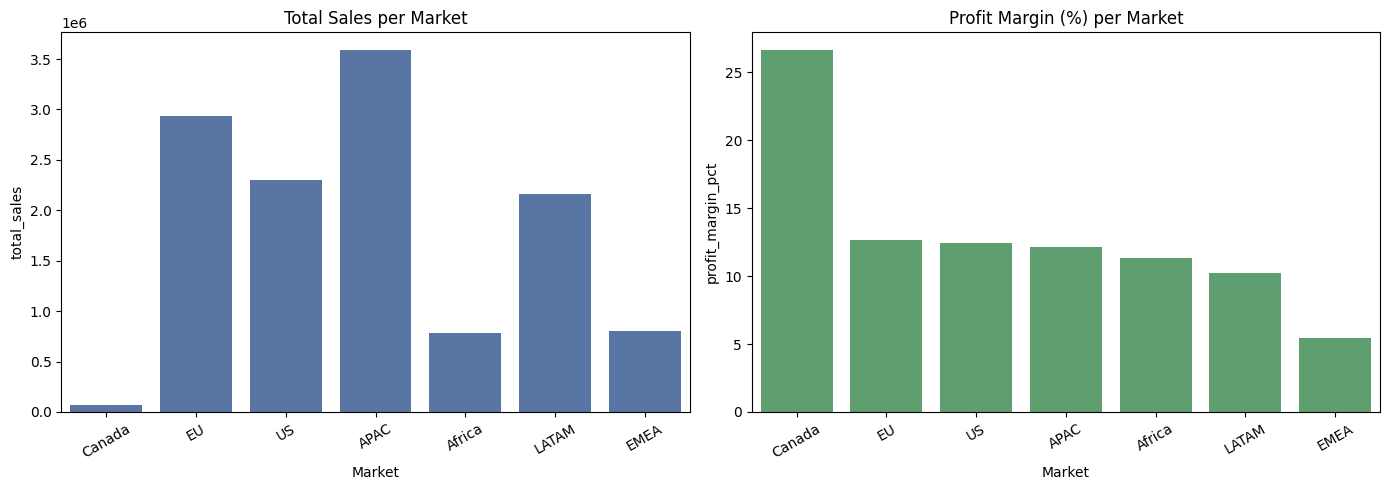

,Market2,total_sales,total_profit,profit_margin_pct
5,North America,2364286,304214.41170,12.87
3,EU,2938139,372829.74150,12.69
0,APAC,3585833,436000.04900,12.16
1,Africa,783776,88871.63100,11.34
4,LATAM,2164687,221643.48708,10.24
2,EMEA,806184,43897.97100,5.45


In [ ]:
market_perf = superstore.groupby("Market", as_index=False).agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    total_orders=("Order ID", "nunique"),
    total_customers=("Customer ID", "nunique"),
)
market_perf["profit_margin_pct"] = (
    market_perf["total_profit"] / market_perf["total_sales"] * 100
).round(2)
market_perf = market_perf.sort_values("profit_margin_pct", ascending=False)
display(market_perf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=market_perf, x="Market", y="total_sales", ax=axes[0], color="#4C72B0")
axes[0].set_title("Total Sales per Market")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=market_perf, x="Market", y="profit_margin_pct", ax=axes[1], color="#55A868")
axes[1].set_title("Profit Margin (%) per Market")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

if "Market2" in superstore.columns:
    market2_perf = superstore.groupby("Market2", as_index=False).agg(
        total_sales=("Sales", "sum"), total_profit=("Profit", "sum"),
    )
    market2_perf["profit_margin_pct"] = (
        market2_perf["total_profit"] / market2_perf["total_sales"] * 100
    ).round(2)
    display(market2_perf.sort_values("profit_margin_pct", ascending=False))

## Profit Margin Analysis (Overall)

Overall Profit Margin seluruh dataset: 11.61%


,Order_Year,total_sales,total_profit,profit_margin_pct
0,2011,2259511,248940.81,11.02
1,2012,2677493,307415.28,11.48
2,2013,3405860,406935.23,11.95
3,2014,4300041,504165.97,11.72


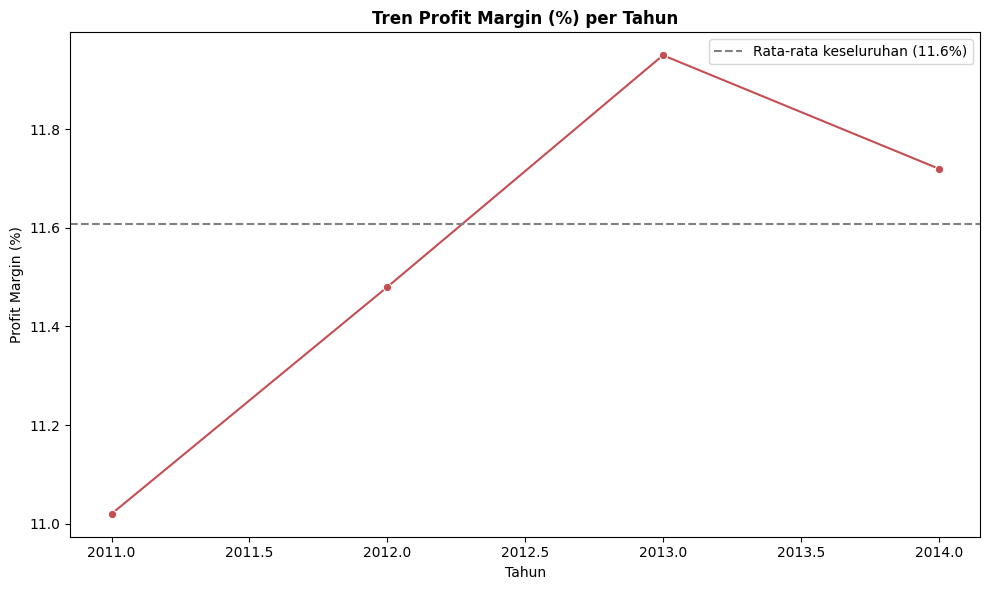

,Category,total_sales,total_profit,profit_margin_pct
0,Furniture,4110884,285204.72,6.94
1,Office Supplies,3787330,518473.83,13.69
2,Technology,4744691,663778.73,13.99


In [ ]:
overall_margin = superstore["Profit"].sum() / superstore["Sales"].sum() * 100
print(f"Overall Profit Margin seluruh dataset: {overall_margin:.2f}%")

margin_by_year = superstore.groupby("Order_Year", as_index=False).agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
)
margin_by_year["profit_margin_pct"] = (
    margin_by_year["total_profit"] / margin_by_year["total_sales"] * 100
)
margin_by_year = margin_by_year.round(2)
display(margin_by_year)

plt.figure(figsize=(10, 6))
sns.lineplot(data=margin_by_year, x="Order_Year", y="profit_margin_pct", marker="o",
             color="#C44E52")
plt.axhline(overall_margin, color="gray", linestyle="--",
            label=f"Rata-rata keseluruhan ({overall_margin:.1f}%)")
plt.title("Tren Profit Margin (%) per Tahun", fontweight="bold")
plt.ylabel("Profit Margin (%)")
plt.xlabel("Tahun")
plt.legend()
plt.tight_layout()
plt.show()

margin_by_category = superstore.groupby("Category", as_index=False).agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
)
margin_by_category["profit_margin_pct"] = (
    margin_by_category["total_profit"] / margin_by_category["total_sales"] * 100
)
margin_by_category = margin_by_category.round(2)
display(margin_by_category.sort_values("profit_margin_pct"))

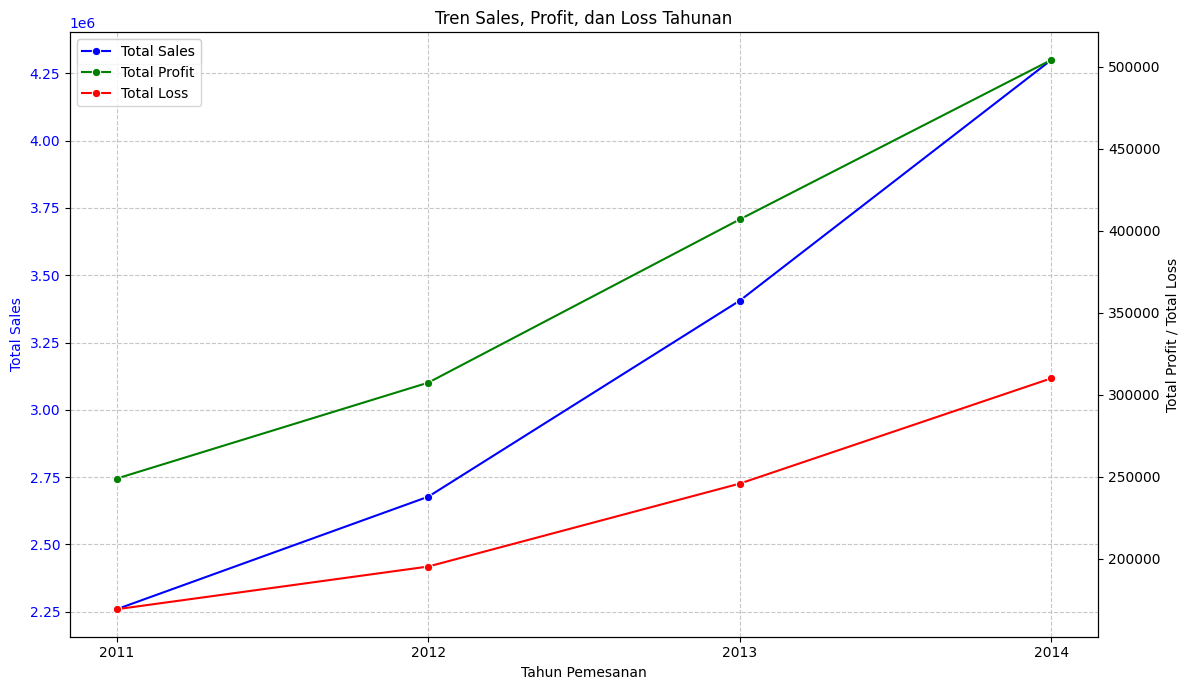

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a new column for absolute loss in yearly_loss
yearly_loss_abs = yearly_loss.copy()
yearly_loss_abs['Total_Loss'] = yearly_loss_abs['Profit'].abs()

# Merge yearly_performance and yearly_loss_abs
yearly_combined = pd.merge(
    yearly_performance,
    yearly_loss_abs[['Order_Year', 'Total_Loss']],
    on='Order_Year',
    how='left'
)

# Rename columns for clarity in plotting
yearly_combined = yearly_combined.rename(columns={
    'Sales': 'Total Sales',
    'Profit': 'Total Profit'
})

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot Total Sales on the first y-axis
sns.lineplot(x='Order_Year', y='Total Sales', data=yearly_combined, marker='o', color='blue', ax=ax1, label='Total Sales')
ax1.set_xlabel('Tahun Pemesanan')
ax1.set_ylabel('Total Sales', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Tren Sales, Profit, dan Loss Tahunan')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_xticks(yearly_combined['Order_Year'].unique()) # Ensure all years are shown as ticks

# Create a second y-axis for Total Profit and Total Loss
ax2 = ax1.twinx()

sns.lineplot(x='Order_Year', y='Total Profit', data=yearly_combined, marker='o', color='green', ax=ax2, label='Total Profit')
sns.lineplot(x='Order_Year', y='Total_Loss', data=yearly_combined, marker='o', color='red', ax=ax2, label='Total Loss')

ax2.set_ylabel('Total Profit / Total Loss', color='black') # Combined label for ax2
ax2.tick_params(axis='y', labelcolor='black')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

# **DASHBOARD**

## Executive Summary

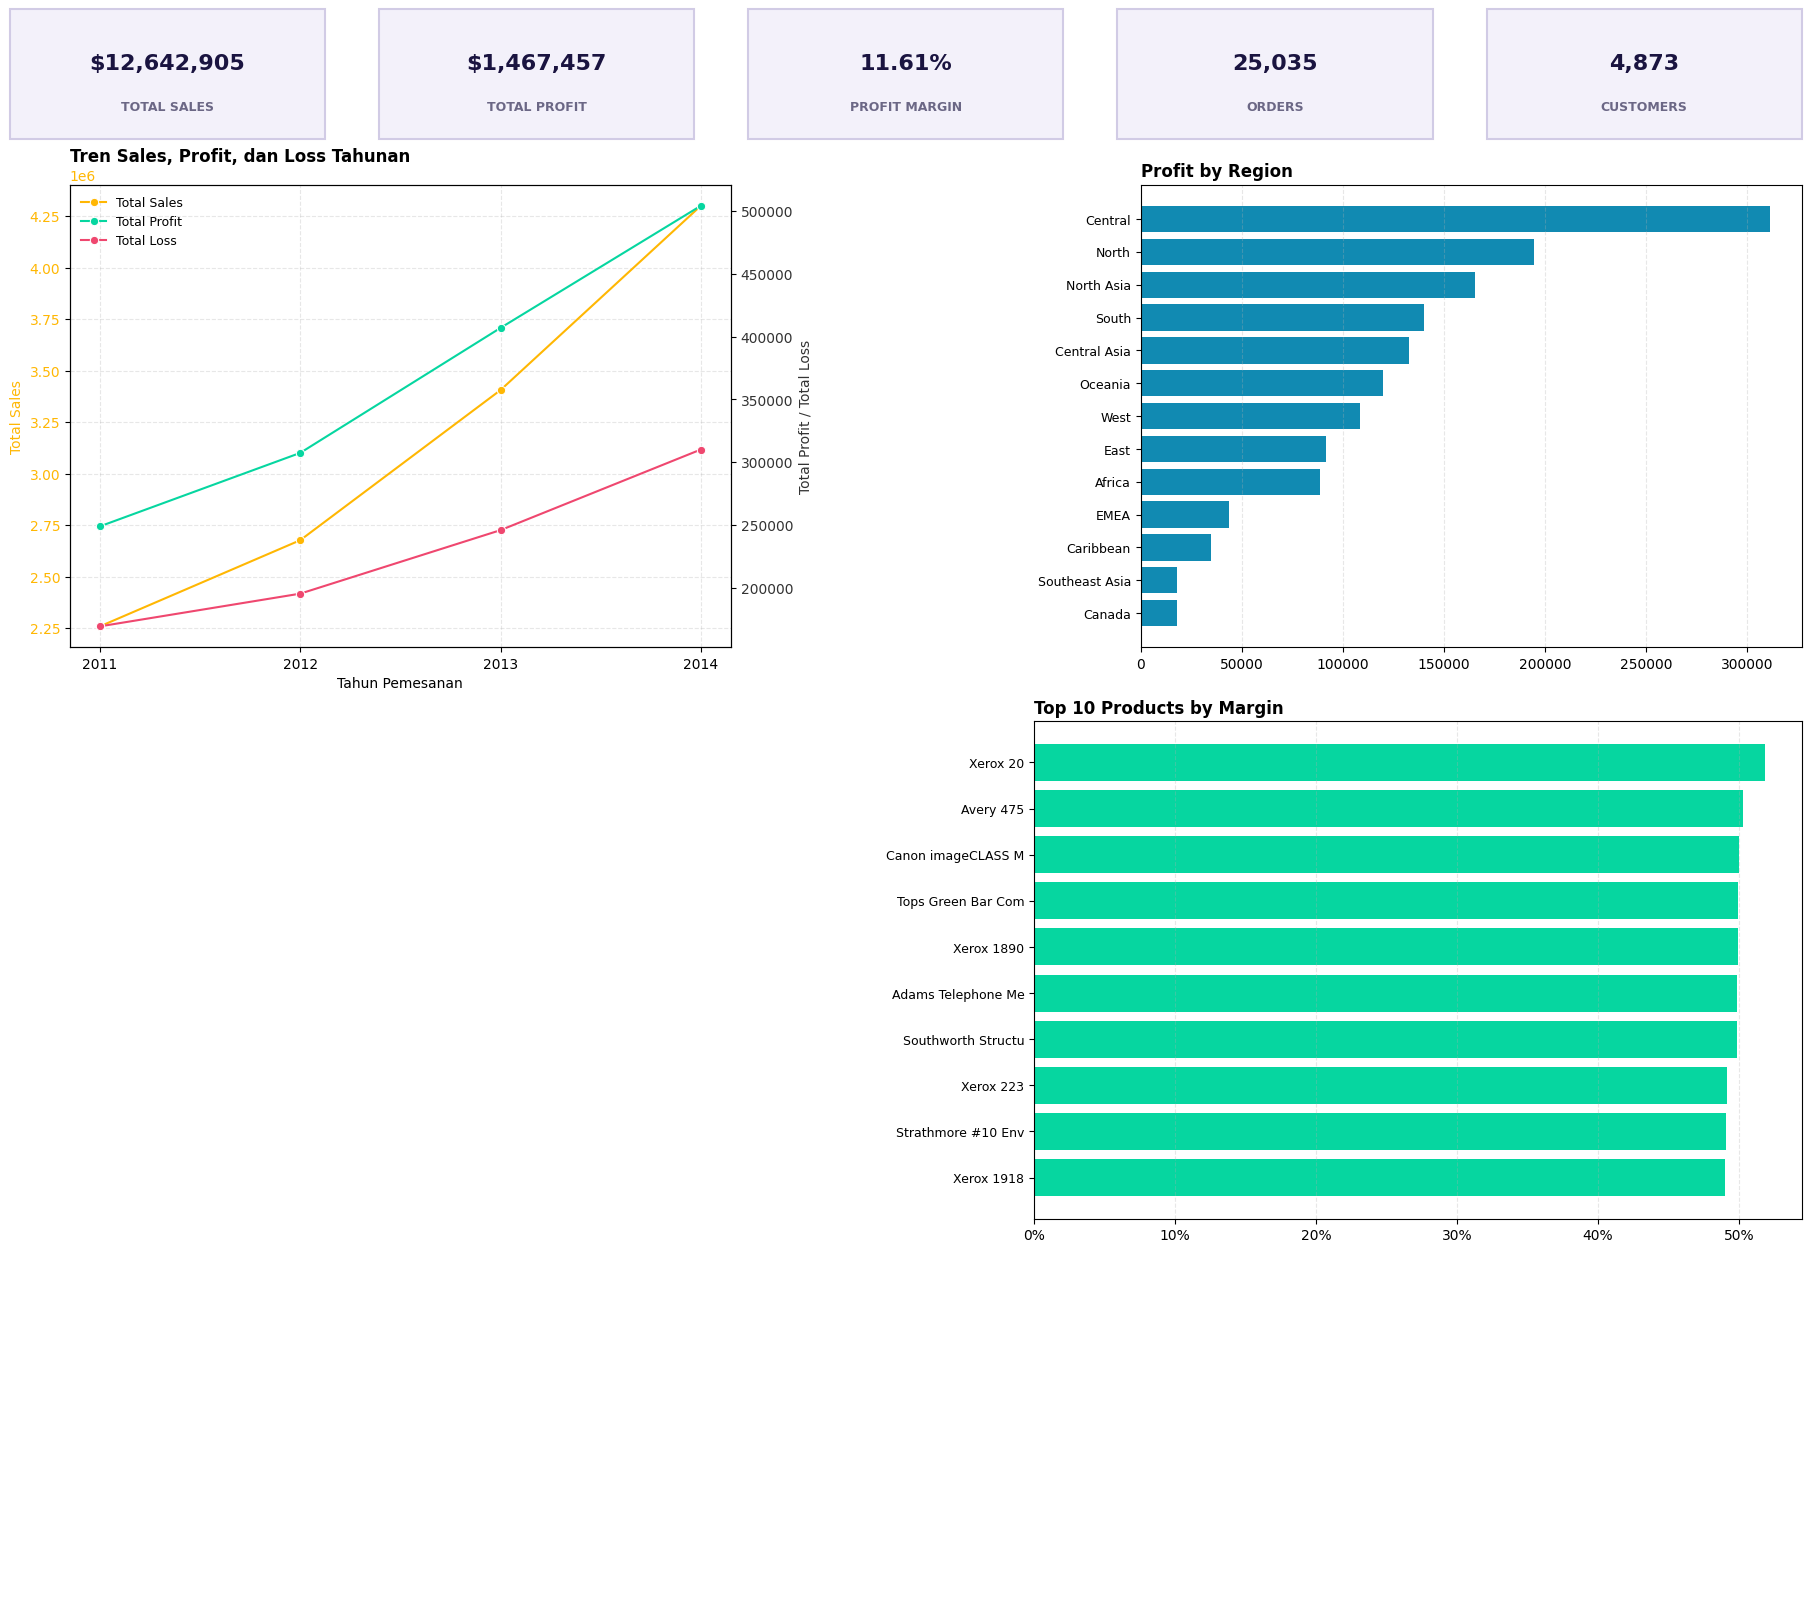

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ======================================================
# KPI & DATA PREPARATION
# ======================================================

sales = superstore["Sales"].sum()
profit = superstore["Profit"].sum()
margin = profit / sales
orders = superstore["Order ID"].nunique()
customers = superstore["Customer ID"].nunique()

loss_df = superstore[superstore["Profit"] < 0]
total_loss_all = loss_df["Profit"].sum()

yearly_performance = superstore.groupby("Order_Year", as_index=False).agg(
    Sales=("Sales", "sum"), Profit=("Profit", "sum")
)
yearly_performance["Margin"] = (
    yearly_performance["Profit"] / yearly_performance["Sales"]
)

yearly_loss = loss_df.groupby("Order_Year", as_index=False).agg(
    Profit=("Profit", "sum")
)
yearly_loss_abs = yearly_loss.copy()
yearly_loss_abs["Total_Loss"] = yearly_loss_abs["Profit"].abs()

yearly_combined = pd.merge(
    yearly_performance,
    yearly_loss_abs[["Order_Year", "Total_Loss"]],
    on="Order_Year",
    how="left",
)
yearly_combined["Total_Loss"] = yearly_combined["Total_Loss"].fillna(0)
yearly_combined = yearly_combined.rename(
    columns={"Sales": "Total Sales", "Profit": "Total Profit"}
)

region = (
    superstore.groupby("Region", as_index=False)
    .agg(Profit=("Profit", "sum"))
    .sort_values("Profit", ascending=True)
)
best_region = region.sort_values("Profit", ascending=False).iloc[0]["Region"]

product_margin = superstore.groupby("Product Name", as_index=False).agg(
    Sales=("Sales", "sum"), Profit=("Profit", "sum")
)
product_margin["Margin"] = (
    product_margin["Profit"] / product_margin["Sales"]
)

top_margin = product_margin.sort_values("Margin", ascending=False).head(10)
top_margin["Product Name Short"] = top_margin["Product Name"].str[:18]

# ======================================================
# FIGURE & LAYOUT (SUBGRIDSPEC)
# ======================================================

fig = plt.figure(figsize=(18, 16), constrained_layout=True)

# Grid Utama (4 Baris)
gs = fig.add_gridspec(4, 1, height_ratios=[0.5, 2, 2, 1.3])

# Subgrid khusus untuk masing-masing baris
gs_kpi = gs[0].subgridspec(1, 5, wspace=0.15)  # 5 KPI Cards Rata
gs_row1 = gs[1].subgridspec(1, 2, wspace=0.25)  # Sales Trend & Region
gs_row2 = gs[2].subgridspec(
    1, 2, wspace=0.25
)  # Profit vs Margin & Top 10 Centered
gs_row3 = gs[3].subgridspec(1, 1)  # Executive Insights

# ======================================================
# KPI CARDS (DIBENARKAN & DIPERBESAR)
# ======================================================

kpi = [
    ("TOTAL SALES", f"${sales:,.0f}"),
    ("TOTAL PROFIT", f"${profit:,.0f}"),
    ("PROFIT MARGIN", f"{margin:.2%}"),
    ("ORDERS", f"{orders:,}"),
    ("CUSTOMERS", f"{customers:,}"),
]

for col_idx, (title, value) in enumerate(kpi):
    ax_kpi = fig.add_subplot(gs_kpi[0, col_idx])

    # Background Card Box
    ax_kpi.add_patch(
        plt.Rectangle(
            (0, 0),
            1,
            1,
            facecolor="#F3F1FA",
            edgecolor="#D1CBE5",
            linewidth=1.5,
            transform=ax_kpi.transAxes,
            clip_on=False,
        )
    )

    # Angka / Value
    ax_kpi.text(
        0.5,
        0.58,
        value,
        ha="center",
        va="center",
        fontsize=16,
        fontweight="bold",
        color="#1A1440",
    )

    # Label / Title
    ax_kpi.text(
        0.5,
        0.25,
        title,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#6B6785",
    )

    ax_kpi.set_xlim(0, 1)
    ax_kpi.set_ylim(0, 1)
    ax_kpi.axis("off")

# ======================================================
# ROW 1, LEFT — Sales, Profit & Loss Trend
# ======================================================

ax1 = fig.add_subplot(gs_row1[0, 0])

sns.lineplot(
    x="Order_Year",
    y="Total Sales",
    data=yearly_combined,
    marker="o",
    color="#FFB703",
    ax=ax1,
    label="Total Sales",
)

ax1.set_xlabel("Tahun Pemesanan")
ax1.set_ylabel("Total Sales", color="#FFB703")
ax1.tick_params(axis="y", labelcolor="#FFB703")
ax1.set_title(
    "Tren Sales, Profit, dan Loss Tahunan",
    fontsize=12,
    fontweight="bold",
    loc="left",
)
ax1.grid(True, linestyle="--", alpha=0.3)
ax1.set_xticks(yearly_combined["Order_Year"].unique())

ax1_twin = ax1.twinx()

sns.lineplot(
    x="Order_Year",
    y="Total Profit",
    data=yearly_combined,
    marker="o",
    color="#06D6A0",
    ax=ax1_twin,
    label="Total Profit",
)

sns.lineplot(
    x="Order_Year",
    y="Total_Loss",
    data=yearly_combined,
    marker="o",
    color="#EF476F",
    ax=ax1_twin,
    label="Total Loss",
)

ax1_twin.set_ylabel("Total Profit / Total Loss", color="#333333")
ax1_twin.tick_params(axis="y", labelcolor="#333333")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()

ax1_twin.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left",
    frameon=False,
    fontsize=9,
)
if ax1.get_legend():
    ax1.get_legend().remove()

# ======================================================
# ROW 1, RIGHT — Profit by Region
# ======================================================

ax_region = fig.add_subplot(gs_row1[0, 1])

ax_region.barh(region["Region"], region["Profit"], color="#118AB2")
ax_region.set_title(
    "Profit by Region", fontsize=12, fontweight="bold", loc="left"
)
ax_region.tick_params(axis="y", labelsize=9)
ax_region.grid(axis="x", linestyle="--", alpha=0.3)

# ======================================================
# ROW 2, RIGHT — Top 10 Products (DITENGAHKAN / DITERAPKAN RAPI)
# ======================================================

ax_top = fig.add_subplot(gs_row2[0, 1])

ax_top.barh(
    top_margin["Product Name Short"], top_margin["Margin"], color="#06D6A0"
)

ax_top.set_title(
    "Top 10 Products by Margin", fontsize=12, fontweight="bold", loc="left"
)
ax_top.invert_yaxis()
ax_top.tick_params(axis="y", labelsize=9)
ax_top.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax_top.grid(axis="x", linestyle="--", alpha=0.3)

# ======================================================
# EXECUTIVE INSIGHT
# ======================================================

ax3 = fig.add_subplot(gs_row3[0, 0])
ax3.axis("off")

# ======================================================
# DASHBOARD
# ======================================================

# ======================================================
# PREPARE DATA
# ======================================================

# country_summary
country_summary = (
    superstore.groupby("Country")
    .agg(
        Total_Sales=("Sales","sum"),
        Total_Profit=("Profit","sum"),
        Total_Customers=("Customer ID","nunique")
    )
    .reset_index()
)

country_summary["Profit_Margin"] = (
    country_summary["Total_Profit"] /
    country_summary["Total_Sales"]
)


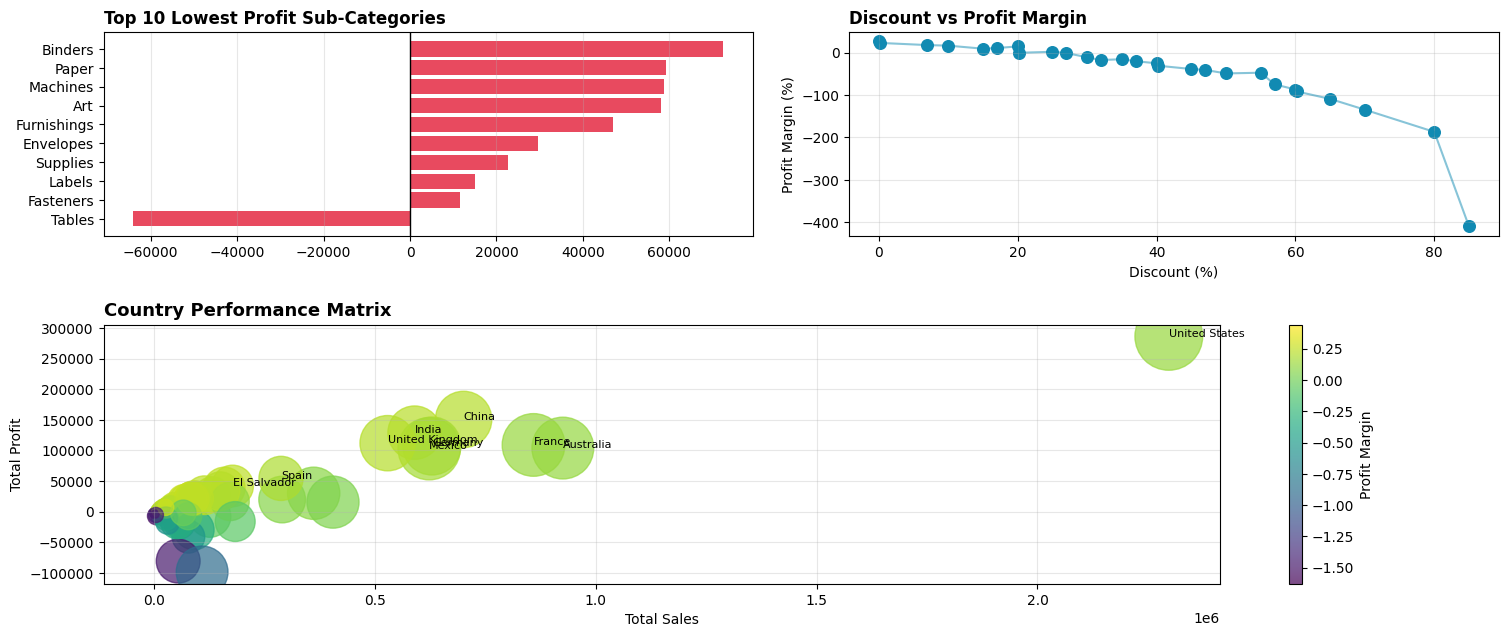

In [ ]:
# ======================================================
# DASHBOARD
# ======================================================

# ======================================================
# PREPARE DATA
# ======================================================

# country_summary
country_summary = (
    superstore.groupby("Country")
    .agg(
        Total_Sales=("Sales","sum"),
        Total_Profit=("Profit","sum"),
        Total_Customers=("Customer ID","nunique")
    )
    .reset_index()
)

country_summary["Profit_Margin"] = (
    country_summary["Total_Profit"] /
    country_summary["Total_Sales"]
)

# ------------------------------------------------------
# Worst Sub Category
# ------------------------------------------------------

subcategory = (
    superstore.groupby("Sub-Category")
    .agg(
        Profit=("Profit","sum")
    )
    .sort_values("Profit")
    .head(10)
)

# ------------------------------------------------------
# Discount vs Margin
# ------------------------------------------------------

discount_margin = (
    superstore.groupby("Discount")
    .agg(
        Margin=("Profit_Margin","mean")
    )
    .reset_index()
)

# ------------------------------------------------------
# Investment Priority
# ------------------------------------------------------

top_country = (
    country_summary.sort_values(
        "Total_Profit",
        ascending=False
    )
    .iloc[0]["Country"]
)

worst_product = (
    subcategory.index[0]
)

# ======================================================
# FIGURE
# ======================================================

fig = plt.figure(figsize=(18,10))

gs = GridSpec(
    3,
    4,
    figure=fig,
    height_ratios=[2.2,2.8,1.4],
    hspace=0.45,
    wspace=0.35
)

# ======================================================
# CHART 1
# Worst Products
# ======================================================

ax1 = fig.add_subplot(gs[0,0:2])

ax1.barh(
    subcategory.index,
    subcategory["Profit"],
    color="#E84A5F"
)

ax1.set_title(
    "Top 10 Lowest Profit Sub-Categories",
    fontsize=12,
    weight="bold",
    loc="left"
)

ax1.grid(axis="x",alpha=.3)

ax1.axvline(
    0,
    color="black",
    linewidth=1
)

# ======================================================
# CHART 2
# Discount vs Margin
# ======================================================

ax2 = fig.add_subplot(gs[0,2:4])

ax2.scatter(
    discount_margin["Discount"]*100,
    discount_margin["Margin"]*100,
    s=70,
    color="#118AB2"
)

ax2.plot(
    discount_margin["Discount"]*100,
    discount_margin["Margin"]*100,
    color="#118AB2",
    alpha=.5
)

ax2.set_title(
    "Discount vs Profit Margin",
    fontsize=12,
    weight="bold",
    loc="left"
)

ax2.set_xlabel("Discount (%)")
ax2.set_ylabel("Profit Margin (%)")

ax2.grid(alpha=.3)

# ======================================================
# CHART 3
# Country Bubble
# ======================================================

ax3 = fig.add_subplot(gs[1,:])

bubble = ax3.scatter(

    country_summary["Total_Sales"],

    country_summary["Total_Profit"],

    s=country_summary["Total_Customers"]*3,

    c=country_summary["Profit_Margin"],

    cmap="viridis",

    alpha=.7

)

plt.colorbar(
    bubble,
    ax=ax3,
    label="Profit Margin"
)

ax3.set_title(

    "Country Performance Matrix",

    fontsize=13,

    weight="bold",

    loc="left"

)

ax3.set_xlabel("Total Sales")

ax3.set_ylabel("Total Profit")

ax3.grid(alpha=.3)

# Label Top 10 Profit Country

top10 = country_summary.nlargest(10,"Total_Profit")

for _,row in top10.iterrows():

    ax3.text(

        row["Total_Sales"],

        row["Total_Profit"],

        row["Country"],

        fontsize=8

    )